In [69]:
# =========================================================
# RANDOM FOREST MODEL FOR HORSE PRICE PREDICTION
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("="*70)
print("RANDOM FOREST MODEL FOR HORSE PRICE PREDICTION")
print("="*70)


# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def find_col(df, candidates):
    """Find column by exact, case-insensitive, or substring match."""
    cols = list(df.columns)
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_numeric_safe(series):
    """Convert series to numeric, handling various formats."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )



# ---------------------------------------------------------
# Load and prepare data
# ---------------------------------------------------------
print("="*70)
print("DATA PREPARATION")
print("="*70)

df = pd.read_excel("Yearlingauctiondata.xlsx")
df.columns = [c.strip() for c in df.columns]
print(f"\nLoaded {len(df)} rows")

# Identify columns
col_price = find_col(df, ["Sales Price", "Hammer Price", "Price"])
col_studfee = find_col(df, ["Sire Stud Fee", "Stud Fee"])
col_dam_earnings = find_col(df, ["Dam Earnings"])
col_dam_best = find_col(df, ["Dam Best Time", "Dam Best"])
col_dam_starts = find_col(df, ["Dam Starts"])
col_dam_1st = find_col(df, ["Dam 1st"])
col_dam_age = find_col(df, ["Dam Age"])
col_age = find_col(df, ["Age in days", "Age"])
col_year = find_col(df, ["Year", "Auction Year"])
col_gender = find_col(df, ["Gender", "Sex"])
col_auction = find_col(df, ["Auction", "Auction House"])
col_siblings_raceage = find_col(df, ["Siblings Raceage"])
col_american_stakes = "American Stakes"  
col_surgery_report = "Surgery Certificate"
col_surgery_severity = "Surgery Severity"
col_xray_status = 'OCD_XRAY'
col_xray_remains = 'Xray_REM'
col_breeder = 'Breeder'
col_sire_first_season = find_col(df, ["First_Season_Flag"])
col_sire_starts = find_col(df, ["Sire Starts"])
col_sire_earnings = find_col(df, ["Sire Earnings"]) 
col_sire_1st = find_col(df, ["Sire 1st"])
col_dam_sire = find_col(df, ["Dams_Sire"])



# BLUP columns
col_dam_blup = find_col(df, ["Dam BLUP", "Dam_BLUP", "DamBLUP"])
col_sire_blup = find_col(df, ["Sire BLUP", "Sire_BLUP", "SireBLUP"])
col_dam_sire_blup = find_col(df, ["Dam Sire BLUP", "Dam_Sire_BLUP", "DamSireBLUP", "Damsire BLUP"])

print(f"\n[BLUP COLUMNS FOUND]")
print(f"  Dam BLUP:      {col_dam_blup}")
print(f"  Sire BLUP:     {col_sire_blup}")
print(f"  Dam Sire BLUP: {col_dam_sire_blup}")



# ---------------------------------------------------------
# Convert columns to numeric
# ---------------------------------------------------------
print("\n[CONVERTING COLUMNS TO NUMERIC]")
numeric_candidates = [
    col_price, col_studfee, col_dam_earnings, col_dam_best, 
    col_dam_starts, col_dam_1st, col_dam_age, col_age, col_siblings_raceage,
    "French Blood", "Inbreeding", "Sibling Earnings", "Sibling Starts",
    "Sibling 1st", "Gdam  Earnings", "Gdam Raceage", "Gdam Offspring 1st",
    "Gdam Offspring Starts", "Ggdam Earnings", "Ggdam Raceage",
    "Ggdam Offspring 1st", "Ggdam Offspring Starts",
    col_dam_blup, col_sire_blup, col_dam_sire_blup,
    col_surgery_report, col_surgery_severity, col_xray_remains,
    col_american_stakes, col_sire_starts, col_sire_earnings, col_sire_1st
]

for col in numeric_candidates:
    if col and col in df.columns:
        if df[col].dtype == 'object':
            print(f"  Converting: {col}")
        df[col] = to_numeric_safe(df[col])

# Target variable
df["log_price"] = np.log(df[col_price])

#Log transform stud fee
df["Log_stud_fee"] = np.log(df[col_studfee])



# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------
print("\n[FEATURE ENGINEERING]")


# Only calculate if dam has raced
df["DamWinPct"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_1st] / df[col_dam_starts],
    np.nan  
)

# Binary indicator for dam never raced
df["Dam_Never_Raced"] = (df[col_dam_starts].isna() | (df[col_dam_starts] == 0)).astype(int)


# Dam earnings pr start 
df["DamEarningsPerStart"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_earnings] / df[col_dam_starts],
    np.nan
)

# Sibling performance - KEEP NaN for missing
df["SiblingEarningsPerStart"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling Earnings"] / df["Sibling Starts"],
    np.nan
)

df["SiblingEarningsPerHorse"] = np.where(
    df[col_siblings_raceage] > 0,
    df["Sibling Earnings"] / df[col_siblings_raceage],
    np.nan
)

df["SiblingWinPct"] = np.where(
    df["Sibling Starts"] > 0,
    df["Sibling 1st"] / df["Sibling Starts"],
    np.nan
)

# Binary indicator for no siblings
df["Siblings_Missing"] = (df[col_siblings_raceage].isna() | (df[col_siblings_raceage] == 0)).astype(int)

# Granddam performance
df["GranddamEarningsPerHorse"] = np.where(
    df["Gdam Raceage"] > 0,
    df["Gdam  Earnings"] / df["Gdam Raceage"],
    np.nan
)

df["GranddamWinPct"] = np.where(
    df["Gdam Offspring Starts"] > 0,
    df["Gdam Offspring 1st"] / df["Gdam Offspring Starts"],
    np.nan
)

# Great-granddam performance
df["GD_Dam_EarningsPerHorse"] = np.where(
    df["Ggdam Raceage"] > 0,
    df["Ggdam Earnings"] / df["Ggdam Raceage"],
    np.nan
)

df["GD_Dam_WinPct"] = np.where(
    df["Ggdam Offspring Starts"] > 0,
    df["Ggdam Offspring 1st"] / df["Ggdam Offspring Starts"],
    np.nan
)

# Sire performance
df["SireWinPct"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_1st] / df[col_sire_starts],
    np.nan
)

df["SireEarningsPerStart"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_earnings] / df[col_sire_starts],
    np.nan
)

#Inverse dam time so that sign is interpretable 
df['dam_time_inverse'] = 1 / df['Dam Best Time']

# Prize money impact 
prize_money_sek = {
    2023: 1.11,
    2024: 1.08,
    2025: 1.19
}

df["Log_Prize_Money"] = np.log(df[col_year].map(prize_money_sek))


# BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    df["Dam_BLUP_Missing"] = df[col_dam_blup].isna().astype(int)
if col_sire_blup and col_sire_blup in df.columns:
    df["Sire_BLUP_Missing"] = df[col_sire_blup].isna().astype(int)
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    df["Dam_Sire_BLUP_Missing"] = df[col_dam_sire_blup].isna().astype(int)

# Categorical encoding
df[col_auction] = df[col_auction].astype(str).str.strip().str.upper()
df["Selective_Auctions"] = df[col_auction].isin(["EY", "SY"]).astype(int)

df[col_gender] = df[col_gender].astype(str).str.strip().str.upper()
df["Gender"] = (df[col_gender] == "H").astype(int)


# ---------------------------------------------------------
# XRAY_RISK_SCORE (deterministic feature)
# ---------------------------------------------------------
print("  Creating XRAY_RISK_SCORE")

# Ensure numeric types (in case they come in as object)
for c in [col_xray_status, col_surgery_report, col_surgery_severity, col_xray_remains]:
    if c in df.columns:
        df[c] = to_numeric_safe(df[c])

# Normalize: SURGERY_SEVERITY should be NaN when no surgery certificate
# (so '0' doesn't carry meaning beyond "not applicable")
if col_surgery_report in df.columns and col_surgery_severity in df.columns:
    df.loc[df[col_surgery_report] == 0, col_surgery_severity] = np.nan

# Compute score components (monotone, clamped to [0,1])
base_risk = np.where(df[col_xray_status] == 1, 0.40, 0.00)
surgery_mitigation = np.where(df[col_surgery_report] == 1, -0.10, 0.00)

# disease burden: only if severity exists (3-5). If NaN -> 0.0
# disease burden (severity)

severity_map = {
    3: 0.10,
    4: 0.30,
    5: 0.60
}

severity_risk = df[col_surgery_severity].map(severity_map).fillna(0.0)



# residual risk: X_RAY_REM assumed 0-3; if missing -> 0 (or NaN if you prefer)
rem = df[col_xray_remains].fillna(0.0)
residual_risk = 0.15 * rem

df["XRAY_RISK_SCORE"] = base_risk + surgery_mitigation + severity_risk + residual_risk
df["XRAY_RISK_SCORE"] = df["XRAY_RISK_SCORE"].clip(lower=0.0, upper=1.0)


print("  Created derived features")

RANDOM FOREST MODEL FOR HORSE PRICE PREDICTION
DATA PREPARATION

Loaded 1618 rows

[BLUP COLUMNS FOUND]
  Dam BLUP:      Dam BLUP
  Sire BLUP:     Sire BLUP
  Dam Sire BLUP: Dam Sire BLUP

[CONVERTING COLUMNS TO NUMERIC]
  Converting: French Blood
  Converting: Inbreeding

[FEATURE ENGINEERING]
  Creating XRAY_RISK_SCORE
  Created derived features


In [70]:
# ---------------------------------------------------------
# Train/Test Split
# ---------------------------------------------------------
TRAIN_YEARS = [2023, 2024]
TEST_YEAR = 2025

train_mask = df[col_year].isin(TRAIN_YEARS)
test_mask = df[col_year] == TEST_YEAR

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

y_train = df_train["log_price"].copy()
y_test = df_test["log_price"].copy()

print(f"[SPLIT]")
print(f"  Train: {len(df_train)} rows ({TRAIN_YEARS})")
print(f"  Test: {len(df_test)} rows ({TEST_YEAR})")

[SPLIT]
  Train: 1108 rows ([2023, 2024])
  Test: 510 rows (2025)


In [71]:
# =========================================================
# BREEDER - SMOOTHED TARGET ENCODING (with LOO for training)
# =========================================================

print("="*70)
print("BREEDER - SMOOTHED TARGET ENCODING")
print("="*70)

# ---------------------------------------------------------
# 1. Calculate breeder statistics on TRAINING DATA
# ---------------------------------------------------------
target = 'log_price'

# Global mean from training data
global_mean_breeder = df_train[target].mean()

# Breeder-level statistics from training data
breeder_stats = df_train.groupby(col_breeder)[target].agg(['sum', 'count', 'std'])
breeder_stats.columns = ['breeder_sum', 'n', 'breeder_std']
breeder_stats['breeder_mean'] = breeder_stats['breeder_sum'] / breeder_stats['n']

print(f"\n[BREEDER STATISTICS (from training data)]")
print(f"  Unique breeders in train: {len(breeder_stats)}")
print(f"  Global mean (log_price):  {global_mean_breeder:.4f}")
print(f"\n  Breeder count distribution:")
print(f"    1 horse:     {(breeder_stats['n'] == 1).sum()} breeders")
print(f"    2-5 horses:  {((breeder_stats['n'] >= 2) & (breeder_stats['n'] <= 5)).sum()} breeders")
print(f"    6-10 horses: {((breeder_stats['n'] >= 6) & (breeder_stats['n'] <= 10)).sum()} breeders")
print(f"    11+ horses:  {(breeder_stats['n'] > 10).sum()} breeders")


# Calculate smoothing parameter (Empirical Bayes)

global_var = df_train[target].var()
within_var = breeder_stats['breeder_std'].mean() ** 2



m_breeder = global_var / within_var if within_var > 0 else 5

print(f"\n[SMOOTHING PARAMETER]")
print(f"  Empirical Bayes m: {m_breeder:.2f}")

# ---------------------------------------------------------
# 3. TRAINING DATA: Leave-One-Out Encoding
# ---------------------------------------------------------
# For each training horse: exclude its own price from breeder mean

# Map breeder totals to each row
train_breeder_sum = df_train[col_breeder].map(breeder_stats['breeder_sum'])
train_breeder_n = df_train[col_breeder].map(breeder_stats['n'])

# LOO mean: (sum - this_horse_price) / (n - 1)
loo_mean = (train_breeder_sum - df_train[target]) / (train_breeder_n - 1)

# For single-horse breeders, LOO mean is undefined → use global mean
loo_mean = loo_mean.fillna(global_mean_breeder)

# Effective sample size for smoothing
loo_n = (train_breeder_n - 1).clip(lower=0)

# Apply smoothing to LOO means
df_train['Breeder_Encoded'] = (loo_n * loo_mean + m_breeder * global_mean_breeder) / (loo_n + m_breeder)
df_train['Breeder_Encoded'] = df_train['Breeder_Encoded'].fillna(global_mean_breeder)

print(f"\n[TRAINING DATA: Leave-One-Out Encoding Applied]")
print(f"  Each horse's encoding excludes its own price")

# ---------------------------------------------------------
# 4. TEST DATA: Standard Encoding (use full training stats)
# ---------------------------------------------------------
# Test horses were never in training, so no LOO needed

def smoothed_target_encode(df, col, stats, global_mean, m):
    """Apply smoothed target encoding using full breeder stats."""
    n = df[col].map(stats['n']).fillna(0)
    breeder_mean = df[col].map(stats['breeder_mean']).fillna(global_mean)
    encoded = (n * breeder_mean + m * global_mean) / (n + m)
    return encoded.fillna(global_mean)

df_test['Breeder_Encoded'] = smoothed_target_encode(
    df_test, col_breeder, breeder_stats, global_mean_breeder, m_breeder
)

# Check for new breeders in test set
train_breeders = set(df_train[col_breeder].unique())
test_breeders = set(df_test[col_breeder].unique())
new_breeders = test_breeders - train_breeders

print(f"\n[TEST DATA: Standard Encoding Applied]")
print(f"  Uses full training breeder statistics")
print(f"  New breeders in test: {len(new_breeders)} (will use global mean)")

# ---------------------------------------------------------
# 5. Summary statistics
# ---------------------------------------------------------
print(f"\n[ENCODED FEATURE STATISTICS]")
print(f"  Train - Mean: {df_train['Breeder_Encoded'].mean():.4f}, Std: {df_train['Breeder_Encoded'].std():.4f}")
print(f"  Test  - Mean: {df_test['Breeder_Encoded'].mean():.4f}, Std: {df_test['Breeder_Encoded'].std():.4f}")

# ---------------------------------------------------------
# 6. Correlation check
# ---------------------------------------------------------
corr_train = df_train['Breeder_Encoded'].corr(df_train['log_price'])
corr_test = df_test['Breeder_Encoded'].corr(df_test['log_price'])

print(f"\n[CORRELATION WITH log_price]")
print(f"  Train (LOO): r = {corr_train:+.4f}  ← No leakage")
print(f"  Test:        r = {corr_test:+.4f}  ← Out-of-sample")

BREEDER - SMOOTHED TARGET ENCODING

[BREEDER STATISTICS (from training data)]
  Unique breeders in train: 309
  Global mean (log_price):  11.7590

  Breeder count distribution:
    1 horse:     147 breeders
    2-5 horses:  119 breeders
    6-10 horses: 26 breeders
    11+ horses:  17 breeders

[SMOOTHING PARAMETER]
  Empirical Bayes m: 2.22

[TRAINING DATA: Leave-One-Out Encoding Applied]
  Each horse's encoding excludes its own price

[TEST DATA: Standard Encoding Applied]
  Uses full training breeder statistics
  New breeders in test: 61 (will use global mean)

[ENCODED FEATURE STATISTICS]
  Train - Mean: 11.7896, Std: 0.4040
  Test  - Mean: 11.8670, Std: 0.3974

[CORRELATION WITH log_price]
  Train (LOO): r = +0.4021  ← No leakage
  Test:        r = +0.2988  ← Out-of-sample


In [72]:
# ---------------------------------------------------------
# Define features for Random Forest
# ---------------------------------------------------------

# Continuous features (these would be smooth terms in GAM)
continuous_features = [
    'French Blood',
    'Inbreeding',
     col_age,
    'Log_stud_fee',
  #  "SireWinPct",
    "SireEarningsPerStart",
#    col_studfee,
    'dam_time_inverse',
    'DamWinPct',
    'DamEarningsPerStart',
    col_dam_age,
    col_sire_blup,
    col_dam_blup,
    col_dam_sire_blup,
    'SiblingEarningsPerStart',
    'SiblingEarningsPerHorse',
    'SiblingWinPct',
    'GranddamEarningsPerHorse',
    'GranddamWinPct',
    'GD_Dam_EarningsPerHorse',
    'GD_Dam_WinPct',
    'XRAY_RISK_SCORE',
    'Breeder_Encoded',  
]

# Binary/categorical features (these would be factor terms in GAM)
binary_features = [
    'Gender',
    'Selective_Auctions',
   'Dam_Never_Raced',
    'Siblings_Missing',
    'Sire_BLUP_Missing', 
    'Dam_BLUP_Missing',
    'Dam_Sire_BLUP_Missing',
    col_american_stakes,
    col_sire_first_season,
 #   "Log_Prize_Money", 
]

# Filter to existing columns
continuous_features = [f for f in continuous_features if f and f in df_train.columns]
binary_features = [f for f in binary_features if f and f in df_train.columns]

print(f"[RANDOM FOREST FEATURES]")
print(f"  Continuous features: {len(continuous_features)}")
for f in continuous_features:
    print(f"    - {f}")
print(f"  Binary features: {len(binary_features)}")
for f in binary_features:
    print(f"    - {f}")

# ---------------------------------------------------------
# Combine into FEATURES list
# ---------------------------------------------------------
FEATURES = continuous_features + binary_features

print(f"\n[TOTAL FEATURES]: {len(FEATURES)}")

# ---------------------------------------------------------
# Create feature matrices
# ---------------------------------------------------------
X_train_raw = df_train[FEATURES].copy()
X_test_raw = df_test[FEATURES].copy()

# Convert any remaining object columns
for col in X_train_raw.columns:
    if X_train_raw[col].dtype == 'object':
        print(f"  Converting {col} to numeric")
        X_train_raw[col] = pd.to_numeric(X_train_raw[col], errors='coerce')
        X_test_raw[col] = pd.to_numeric(X_test_raw[col], errors='coerce')

# Handle infinities
X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

print(f"\n[FEATURE MATRICES]")
print(f"  X_train_raw: {X_train_raw.shape}")
print(f"  X_test_raw:  {X_test_raw.shape}")

[RANDOM FOREST FEATURES]
  Continuous features: 21
    - French Blood
    - Inbreeding
    - Age in days
    - Log_stud_fee
    - SireEarningsPerStart
    - dam_time_inverse
    - DamWinPct
    - DamEarningsPerStart
    - Dam Age
    - Sire BLUP
    - Dam BLUP
    - Dam Sire BLUP
    - SiblingEarningsPerStart
    - SiblingEarningsPerHorse
    - SiblingWinPct
    - GranddamEarningsPerHorse
    - GranddamWinPct
    - GD_Dam_EarningsPerHorse
    - GD_Dam_WinPct
    - XRAY_RISK_SCORE
    - Breeder_Encoded
  Binary features: 9
    - Gender
    - Selective_Auctions
    - Dam_Never_Raced
    - Siblings_Missing
    - Sire_BLUP_Missing
    - Dam_BLUP_Missing
    - Dam_Sire_BLUP_Missing
    - American Stakes
    - First_Season_Flag

[TOTAL FEATURES]: 30

[FEATURE MATRICES]
  X_train_raw: (1108, 30)
  X_test_raw:  (510, 30)


In [73]:
# =========================================================
# SMART MISSING VALUE IMPUTATION
# =========================================================

print("="*70)
print("SMART MISSING VALUE IMPUTATION")
print("="*70)

# ---------------------------------------------------------
# 1. Informative missingness: Impute with 0
# ---------------------------------------------------------
print("\n[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]")

zero_impute_cols = [
    'SiblingEarningsPerHorse',
    'SiblingEarningsPerStart', 
    'SiblingWinPct',
    'dam_time_inverse',
    'DamEarningsPerStart',
    'DamWinPct',
]

for col in zero_impute_cols:
    if col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        X_train_raw[col] = X_train_raw[col].fillna(0)
        X_test_raw[col] = X_test_raw[col].fillna(0)
        print(f"  {col}: {n_missing} → filled with 0")

# ---------------------------------------------------------
# 2. Regular missingness: Impute with median
# ---------------------------------------------------------
print("\n[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]")

median_impute_cols = [
    'GranddamEarningsPerHorse',
    'GranddamWinPct',
    'GD_Dam_EarningsPerHorse',
    'GD_Dam_WinPct',
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    'XRAY_RISK_SCORE',
]

for col in median_impute_cols:
    if col and col in X_train_raw.columns:
        n_missing = X_train_raw[col].isna().sum()
        if n_missing > 0:
            median_val = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(median_val)
            X_test_raw[col] = X_test_raw[col].fillna(median_val)
            print(f"  {col}: {n_missing} → filled with median ({median_val:.2f})")

# ---------------------------------------------------------
# 3. Final check
# ---------------------------------------------------------
print(f"\n[VERIFICATION]")
print(f"  X_train NaN remaining: {X_train_raw.isna().sum().sum()}")
print(f"  X_test NaN remaining:  {X_test_raw.isna().sum().sum()}")

# Now create X_train, X_test
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

SMART MISSING VALUE IMPUTATION

[INFORMATIVE MISSINGNESS → IMPUTE WITH 0]
  SiblingEarningsPerHorse: 331 → filled with 0
  SiblingEarningsPerStart: 450 → filled with 0
  SiblingWinPct: 450 → filled with 0
  dam_time_inverse: 150 → filled with 0
  DamEarningsPerStart: 158 → filled with 0
  DamWinPct: 152 → filled with 0

[REGULAR MISSINGNESS → IMPUTE WITH MEDIAN]
  GranddamEarningsPerHorse: 49 → filled with median (741201.67)
  GranddamWinPct: 53 → filled with median (0.16)
  GD_Dam_EarningsPerHorse: 35 → filled with median (886150.50)
  GD_Dam_WinPct: 41 → filled with median (0.16)
  Dam BLUP: 229 → filled with median (107.00)
  Sire BLUP: 156 → filled with median (118.00)
  Dam Sire BLUP: 46 → filled with median (110.00)

[VERIFICATION]
  X_train NaN remaining: 0
  X_test NaN remaining:  0


In [74]:
# =========================================================
# RANDOM FOREST: STEPWISE HYPERPARAMETER TUNING + OOF SIGMA
# =========================================================
# 
# This file contains:
#   1. Stepwise hyperparameter tuning approach (R²-based)
#   2. OOF sigma2 estimation
#   3. Price-scale conversion with bias correction
#   4. Smearing estimator alternative
#
# Copy the relevant sections into your notebook

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# STEPWISE HYPERPARAMETER TUNING FOR RANDOM FOREST
# =========================================================
#
# Why stepwise? Random Forest has many hyperparameters with different
# effects. Tuning them in a structured order is more efficient than
# searching a massive grid all at once.
#
# TUNING ORDER (from most to least impactful):
#   Step 1: n_estimators (more trees = better, diminishing returns)
#   Step 2: max_depth + min_samples_leaf (main regularization)
#   Step 3: max_features (controls tree correlation)
#   Step 4: max_samples (bootstrap sample size)
#   Step 5: min_samples_split (secondary regularization)
#
# =========================================================

print("="*70)
print("STEPWISE HYPERPARAMETER TUNING")
print("="*70)

# Setup CV with GroupKFold (same as your XGBoost)
cv = GroupKFold(n_splits=2)
groups = df_train["Year"].values

# Helper function for evaluation - using R²
def evaluate_params(params, X, y, groups, cv, verbose=True):
    """Evaluate RF parameters using CV, return mean R²."""
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1, criterion='absolute_error')
    scores = cross_val_score(model, X, y, cv=cv, groups=groups, scoring='r2')
    mean_score = scores.mean()
    std_score = scores.std()
    if verbose:
        print(f"    CV R²: {mean_score:.4f} (±{std_score:.4f})")
    return mean_score

# ---------------------------------------------------------
# STEP 1: Find sufficient n_estimators
# ---------------------------------------------------------
# Start with enough trees. More trees generally don't hurt
# (just slower), but we want to find where returns diminish.

print("\n[STEP 1: n_estimators]")
print("  Finding optimal number of trees...")

base_params = {
    'max_depth': 15,           # Start with moderate depth
    'min_samples_leaf': 5,     # Moderate regularization
    'max_features': 'sqrt',    # Default, good starting point
}

n_estimators_values = [100, 200, 300, 500, 800, 1000]
step1_results = []

for n_est in n_estimators_values:
    params = {**base_params, 'n_estimators': n_est}
    print(f"  Testing n_estimators={n_est}:")
    r2 = evaluate_params(params, X_train.values, y_train.values, groups, cv)
    step1_results.append((n_est, r2))

# Find best (highest R²)
best_n_est = max(step1_results, key=lambda x: x[1])[0]
print(f"\n  → Best n_estimators: {best_n_est}")

# Check for diminishing returns
for i in range(1, len(step1_results)):
    improvement = (step1_results[i][1] - step1_results[i-1][1]) / abs(step1_results[i-1][1])
    if improvement < 0.005:  # Less than 0.5% improvement
        print(f"  → Diminishing returns after {step1_results[i-1][0]} trees")
        best_n_est = step1_results[i-1][0]
        break

# ---------------------------------------------------------
# STEP 2: Tune max_depth + min_samples_leaf jointly
# ---------------------------------------------------------
# These are the primary regularization parameters.
# They interact strongly, so tune together.

print("\n[STEP 2: max_depth + min_samples_leaf]")
print("  These control overfitting - tuning jointly...")

depth_values = [8, 10, 12, 15, 20, None]  # None = unlimited
leaf_values = [1, 2, 5, 10, 15, 20]

step2_results = []

for depth in depth_values:
    for leaf in leaf_values:
        params = {
            'n_estimators': best_n_est,
            'max_depth': depth,
            'min_samples_leaf': leaf,
            'max_features': 'sqrt',
        }
        depth_str = str(depth) if depth else 'None'
        print(f"  Testing depth={depth_str}, leaf={leaf}:", end=" ")
        r2 = evaluate_params(params, X_train.values, y_train.values, groups, cv, verbose=False)
        print(f"R²={r2:.4f}")
        step2_results.append((depth, leaf, r2))

best_depth, best_leaf, _ = max(step2_results, key=lambda x: x[2])
print(f"\n  → Best: max_depth={best_depth}, min_samples_leaf={best_leaf}")

# ---------------------------------------------------------
# STEP 3: Tune max_features
# ---------------------------------------------------------
# Controls how correlated trees are.
# Lower = less correlated but potentially weaker trees.

print("\n[STEP 3: max_features]")
print("  Controls tree diversity...")

n_features = X_train.shape[1]
max_features_values = [
    'sqrt',                         # sqrt(n_features)
    'log2',                         # log2(n_features)
    int(n_features * 0.3),          # 30%
    int(n_features * 0.5),          # 50%
    int(n_features * 0.7),          # 70%
    None,                           # All features
]

step3_results = []

for max_feat in max_features_values:
    params = {
        'n_estimators': best_n_est,
        'max_depth': best_depth,
        'min_samples_leaf': best_leaf,
        'max_features': max_feat,
    }
    feat_str = str(max_feat) if isinstance(max_feat, (int, str)) or max_feat is None else f"{max_feat:.1%}"
    print(f"  Testing max_features={feat_str}:", end=" ")
    r2 = evaluate_params(params, X_train.values, y_train.values, groups, cv, verbose=False)
    print(f"R²={r2:.4f}")
    step3_results.append((max_feat, r2))

best_max_feat, _ = max(step3_results, key=lambda x: x[1])
print(f"\n  → Best: max_features={best_max_feat}")

# ---------------------------------------------------------
# STEP 4: Tune max_samples (bootstrap fraction)
# ---------------------------------------------------------
# Lower values add more randomness (like subsampling in XGBoost).

print("\n[STEP 4: max_samples]")
print("  Bootstrap sample size...")

max_samples_values = [0.5, 0.6, 0.7, 0.8, 0.9, None]  # None = full dataset

step4_results = []

for max_samp in max_samples_values:
    params = {
        'n_estimators': best_n_est,
        'max_depth': best_depth,
        'min_samples_leaf': best_leaf,
        'max_features': best_max_feat,
        'max_samples': max_samp,
        'bootstrap': True,  # Required for max_samples
    }
    samp_str = str(max_samp) if max_samp else 'None (100%)'
    print(f"  Testing max_samples={samp_str}:", end=" ")
    r2 = evaluate_params(params, X_train.values, y_train.values, groups, cv, verbose=False)
    print(f"R²={r2:.4f}")
    step4_results.append((max_samp, r2))

best_max_samp, _ = max(step4_results, key=lambda x: x[1])
print(f"\n  → Best: max_samples={best_max_samp}")

# ---------------------------------------------------------
# STEP 5: Fine-tune min_samples_split (optional)
# ---------------------------------------------------------
# Secondary regularization. Usually less impactful.

print("\n[STEP 5: min_samples_split (fine-tuning)]")

split_values = [2, 5, 10, 15, 20]

step5_results = []

for split in split_values:
    params = {
        'n_estimators': best_n_est,
        'max_depth': best_depth,
        'min_samples_leaf': best_leaf,
        'max_features': best_max_feat,
        'max_samples': best_max_samp,
        'bootstrap': True,
        'min_samples_split': split,
    }
    print(f"  Testing min_samples_split={split}:", end=" ")
    r2 = evaluate_params(params, X_train.values, y_train.values, groups, cv, verbose=False)
    print(f"R²={r2:.4f}")
    step5_results.append((split, r2))

best_split, _ = max(step5_results, key=lambda x: x[1])
print(f"\n  → Best: min_samples_split={best_split}")

# ---------------------------------------------------------
# FINAL BEST PARAMETERS
# ---------------------------------------------------------
print("\n" + "="*70)
print("FINAL TUNED PARAMETERS")
print("="*70)

best_params = {
    'n_estimators': best_n_est,
    'max_depth': best_depth,
    'min_samples_leaf': best_leaf,
    'max_features': best_max_feat,
    'max_samples': best_max_samp,
    'min_samples_split': best_split,
    'bootstrap': True,
    'random_state': 42,
    'n_jobs': -1,
}

print("\nbest_params = {")
for k, v in best_params.items():
    if isinstance(v, str):
        print(f"    '{k}': '{v}',")
    else:
        print(f"    '{k}': {v},")
print("}")

# ---------------------------------------------------------
# Train final model
# ---------------------------------------------------------
print("\n[TRAINING FINAL MODEL]")

best_model = RandomForestRegressor(**best_params)
best_model.fit(X_train.values, y_train.values)

pred_train_tuned = best_model.predict(X_train.values)
pred_test_tuned = best_model.predict(X_test.values)

train_r2 = r2_score(y_train, pred_train_tuned)
test_r2 = r2_score(y_test, pred_test_tuned)
test_mae = mean_absolute_error(y_test, pred_test_tuned)

print(f"\n  Train R²: {train_r2:.4f}")
print(f"  Test R²:  {test_r2:.4f}")
print(f"  Gap:      {train_r2 - test_r2:.4f}")
print(f"  Test MAE: {test_mae:.4f}")


# =========================================================
# OUT-OF-FOLD SIGMA2 ESTIMATION (matching XGBoost code)
# =========================================================

print("\n" + "="*70)
print("OUT-OF-FOLD SIGMA2 ESTIMATION")
print("="*70)

# Create model with tuned parameters for OOF prediction
oof_model = RandomForestRegressor(**best_params)

# Get OOF predictions using GroupKFold (same as tuning)
cv = GroupKFold(n_splits=2)  # Same as your XGBoost
groups = df_train["Year"].values

oof_predictions = cross_val_predict(
    oof_model, 
    X_train.values, 
    y_train.values, 
    cv=cv, 
    groups=groups
)

# Calculate OOF residuals and sigma2
oof_residuals = y_train.values - oof_predictions
sigma2_oof = np.var(oof_residuals)

# Compare all three
sigma2_train = np.var(y_train.values - pred_train_tuned)
sigma2_test = np.var(y_test.values - pred_test_tuned)

print(f"\n[SIGMA2 COMPARISON]")
print(f"  {'Method':<20} {'σ2':>10} {'Correction':>12}")
print(f"  {'-'*20} {'-'*10} {'-'*12}")
print(f"  {'Training (in-sample)':<20} {sigma2_train:>10.4f} {np.exp(sigma2_train/2):>12.4f}")
print(f"  {'OOF (out-of-fold)':<20} {sigma2_oof:>10.4f} {np.exp(sigma2_oof/2):>12.4f}")
print(f"  {'Test (diagnostic)':<20} {sigma2_test:>10.4f} {np.exp(sigma2_test/2):>12.4f}")

print(f"\n[RECOMMENDATION]")
if sigma2_oof > sigma2_train * 1.5:
    print(f"  OOF σ2 is {sigma2_oof/sigma2_train:.1f}x larger than training σ2")
    print(f"  → Use OOF σ2 = {sigma2_oof:.4f} for more realistic correction")
else:
    print(f"  OOF and training σ2 are similar")
    print(f"  → Training σ2 is acceptable, but OOF is still preferred")

# ---------------------------------------------------------
# PRICE SCALE CONVERSION
# ---------------------------------------------------------
# Actual prices
y_train_price = np.exp(y_train.values)
y_test_price = np.exp(y_test.values)

# === METHOD 2b: Sigma2/2 correction using OOF estimate ===
sigma2 = sigma2_oof  # Use OOF instead of training
pred_train_price_tuned = np.exp(pred_train_tuned + sigma2/2)
pred_test_price_tuned = np.exp(pred_test_tuned + sigma2/2)
conversion_method = f"Sigma2/2 correction (OOF σ2={sigma2:.4f})"
correction_factor = np.exp(sigma2/2)

print(f"\n[PRICE SCALE CONVERSION]")
print(f"  Method: {conversion_method}")
print(f"  Correction factor: {correction_factor:.4f}")

# ---------------------------------------------------------
# FINAL METRICS ON PRICE SCALE
# ---------------------------------------------------------
test_r2_price = r2_score(y_test_price, pred_test_price_tuned)
rmse_price = np.sqrt(mean_squared_error(y_test_price, pred_test_price_tuned))
mae_price = mean_absolute_error(y_test_price, pred_test_price_tuned)
mean_error = np.mean(pred_test_price_tuned - y_test_price)
median_error = np.median(pred_test_price_tuned - y_test_price)

print(f"\n[PRICE SCALE METRICS (with OOF correction)]")
print(f"  Test R²:      {test_r2_price:.4f}")
print(f"  RMSE:         {rmse_price:,.0f} NOK")
print(f"  MAE:          {mae_price:,.0f} NOK")
print(f"  Mean Error:   {mean_error:+,.0f} NOK")
print(f"  Median Error: {median_error:+,.0f} NOK")


# =========================================================
# ALTERNATIVE: SMEARING ESTIMATOR WITH OOF RESIDUALS
# =========================================================
# You can also use OOF residuals for Duan's smearing

print("\n" + "-"*70)
print("ALTERNATIVE: OOF-BASED SMEARING")
print("-"*70)

# Smearing using OOF residuals (more conservative)
smearing_factor_oof = np.mean(np.exp(oof_residuals))
pred_test_price_smearing = np.exp(pred_test_tuned) * smearing_factor_oof

print(f"\n  Smearing factor (OOF): {smearing_factor_oof:.4f}")
print(f"  vs σ2/2 correction:   {correction_factor:.4f}")

mae_smearing = mean_absolute_error(y_test_price, pred_test_price_smearing)
mean_error_smearing = np.mean(pred_test_price_smearing - y_test_price)

print(f"\n  [Smearing Metrics]")
print(f"    MAE:        {mae_smearing:,.0f} NOK")
print(f"    Mean Error: {mean_error_smearing:+,.0f} NOK")


# =========================================================
# SUMMARY: WHICH SIGMA TO USE
# =========================================================
print("\n" + "="*70)
print("SUMMARY: SIGMA SELECTION GUIDE")
print("="*70)

STEPWISE HYPERPARAMETER TUNING

[STEP 1: n_estimators]
  Finding optimal number of trees...
  Testing n_estimators=100:
    CV R²: 0.5005 (±0.0395)
  Testing n_estimators=200:
    CV R²: 0.5080 (±0.0413)
  Testing n_estimators=300:
    CV R²: 0.5096 (±0.0436)
  Testing n_estimators=500:
    CV R²: 0.5102 (±0.0416)
  Testing n_estimators=800:
    CV R²: 0.5106 (±0.0426)
  Testing n_estimators=1000:
    CV R²: 0.5111 (±0.0428)

  → Best n_estimators: 1000
  → Diminishing returns after 200 trees

[STEP 2: max_depth + min_samples_leaf]
  These control overfitting - tuning jointly...
  Testing depth=8, leaf=1: R²=0.5191
  Testing depth=8, leaf=2: R²=0.5160
  Testing depth=8, leaf=5: R²=0.5071
  Testing depth=8, leaf=10: R²=0.4973
  Testing depth=8, leaf=15: R²=0.4802
  Testing depth=8, leaf=20: R²=0.4667
  Testing depth=10, leaf=1: R²=0.5205
  Testing depth=10, leaf=2: R²=0.5159
  Testing depth=10, leaf=5: R²=0.5052
  Testing depth=10, leaf=10: R²=0.4967
  Testing depth=10, leaf=15: R²=0.48

In [75]:
# =========================================================
# PREDICTIONS FOR EACH HORSE IN TEST SET (TUNED MODEL)
# =========================================================

print("="*70)
print("INDIVIDUAL HORSE PREDICTIONS (TUNED MODEL)")
print("="*70)

# Create predictions dataframe
predictions_df = pd.DataFrame({
    'Actual_Price_NOK': np.exp(y_test),
    'Predicted_Price_NOK': pred_test_price_tuned,
    'Error_NOK': pred_test_price_tuned - np.exp(y_test),
    'Error_Pct': ((pred_test_price_tuned - np.exp(y_test)) / np.exp(y_test)) * 100,
    'Abs_Error_NOK': np.abs(pred_test_price_tuned - np.exp(y_test)),
    'Abs_Error_Pct': np.abs((pred_test_price_tuned - np.exp(y_test)) / np.exp(y_test)) * 100,
    'Log_Actual': y_test,
    'Log_Predicted': pred_test_tuned
}, index=y_test.index)

# Add horse identifiers if available in original dataframe
identifier_cols = ['Horse', 'Name', col_year, col_auction, col_gender, col_age]
for col in identifier_cols:
    if col and col in df.columns:
        predictions_df[col] = df.loc[y_test.index, col]

# Sort by absolute error (worst predictions first)
predictions_df_sorted = predictions_df.sort_values('Abs_Error_NOK', ascending=False)

print(f"\nTotal predictions: {len(predictions_df)}")

print(f"\n[SUMMARY STATISTICS]")
print(f"  Mean Absolute Error:    {predictions_df['Abs_Error_NOK'].mean():,.0f} NOK")
print(f"  Median Absolute Error:  {predictions_df['Abs_Error_NOK'].median():,.0f} NOK")
print(f"  Mean Error %:           {predictions_df['Error_Pct'].mean():.1f}%")
print(f"  Median Abs Error %:     {predictions_df['Abs_Error_Pct'].median():.1f}%")

print(f"\n[TOP 10 WORST PREDICTIONS - OVERPRICED]")
print("(Model predicted higher than actual price)")
overpriced = predictions_df_sorted[predictions_df_sorted['Error_NOK'] > 0].head(10)
for idx, row in overpriced.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

print(f"\n[TOP 10 WORST PREDICTIONS - UNDERPRICED]")
print("(Model predicted lower than actual price)")
underpriced = predictions_df_sorted[predictions_df_sorted['Error_NOK'] < 0].head(10)
for idx, row in underpriced.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

print(f"\n[BEST 10 PREDICTIONS]")
best = predictions_df.sort_values('Abs_Error_NOK').head(10)
for idx, row in best.iterrows():
    print(f"  Index {idx}: Actual={row['Actual_Price_NOK']:,.0f} NOK, "
          f"Predicted={row['Predicted_Price_NOK']:,.0f} NOK, "
          f"Error={row['Error_Pct']:+.1f}%")

# Save to Excel
predictions_df_sorted.to_excel('rf_tuned_predictions.xlsx', index=True)
print(f"\n✓ Predictions saved to rf_tuned_predictions.xlsx")

# Display first few rows
print(f"\n[FIRST 20 PREDICTIONS]")
display_cols = ['Actual_Price_NOK', 'Predicted_Price_NOK', 'Error_NOK', 'Error_Pct']
if col_year in predictions_df.columns:
    display_cols.insert(0, col_year)
print(predictions_df_sorted[display_cols].head(20).to_string())

INDIVIDUAL HORSE PREDICTIONS (TUNED MODEL)

Total predictions: 510

[SUMMARY STATISTICS]
  Mean Absolute Error:    152,470 NOK
  Median Absolute Error:  86,237 NOK
  Mean Error %:           58.1%
  Median Abs Error %:     54.9%

[TOP 10 WORST PREDICTIONS - OVERPRICED]
(Model predicted higher than actual price)
  Index 1453: Actual=380,000 NOK, Predicted=1,369,131 NOK, Error=+260.3%
  Index 1590: Actual=400,000 NOK, Predicted=1,348,153 NOK, Error=+237.0%
  Index 1503: Actual=400,000 NOK, Predicted=976,203 NOK, Error=+144.1%
  Index 1206: Actual=70,000 NOK, Predicted=638,750 NOK, Error=+812.5%
  Index 1524: Actual=240,000 NOK, Predicted=715,495 NOK, Error=+198.1%
  Index 1545: Actual=50,000 NOK, Predicted=497,925 NOK, Error=+895.9%
  Index 1581: Actual=280,000 NOK, Predicted=679,453 NOK, Error=+142.7%
  Index 1306: Actual=110,000 NOK, Predicted=500,412 NOK, Error=+354.9%
  Index 1153: Actual=600,000 NOK, Predicted=988,477 NOK, Error=+64.7%
  Index 1586: Actual=60,000 NOK, Predicted=434,2

PERMUTATION IMPORTANCE

[CALCULATING PERMUTATION IMPORTANCE]
  Running 30 permutations per feature (this may take a minute)...

[TOP 15 FEATURES BY PERMUTATION IMPORTANCE]
                Feature  Importance_Mean  Importance_Std
           Log_stud_fee         0.254667        0.029072
     Selective_Auctions         0.069269        0.011083
                 Gender         0.029444        0.006733
               Dam BLUP         0.023851        0.006334
              Sire BLUP         0.019344        0.005978
        Breeder_Encoded         0.017665        0.009377
   SireEarningsPerStart         0.007800        0.003848
SiblingEarningsPerStart         0.006688        0.002140
         GranddamWinPct         0.006394        0.003252
        XRAY_RISK_SCORE         0.005737        0.001372
SiblingEarningsPerHorse         0.004869        0.002132
    DamEarningsPerStart         0.004866        0.003777
          GD_Dam_WinPct         0.002637        0.002968
          Dam Sire BLUP       

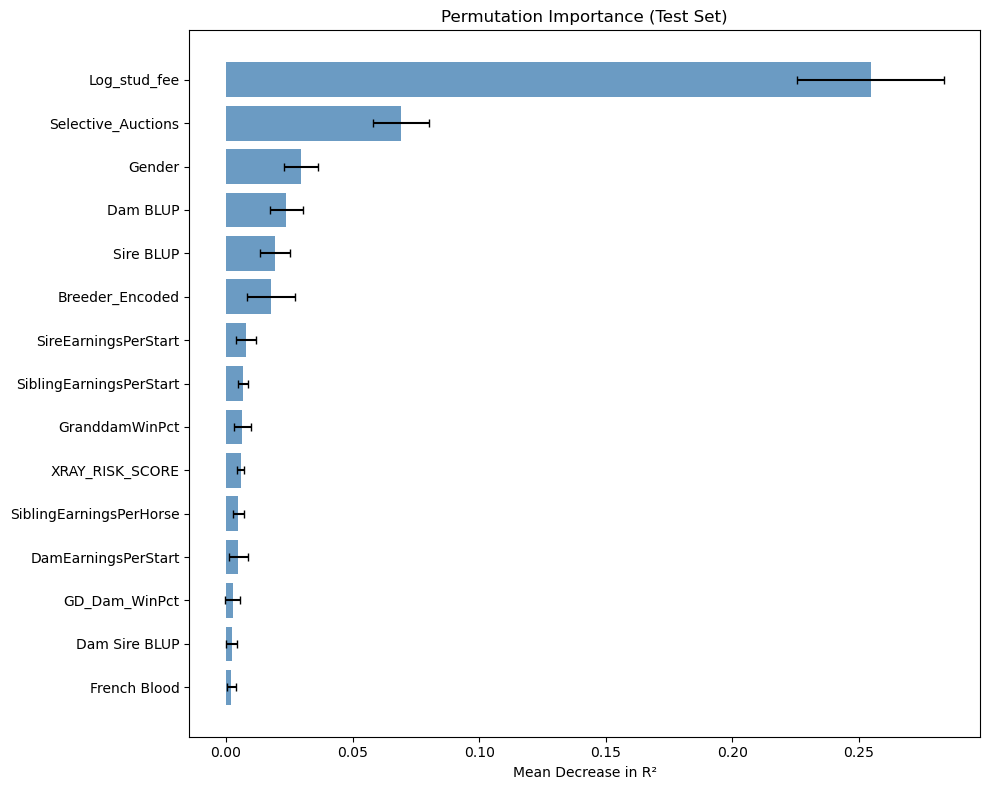


[COMPARISON: MDI vs PERMUTATION IMPORTANCE]


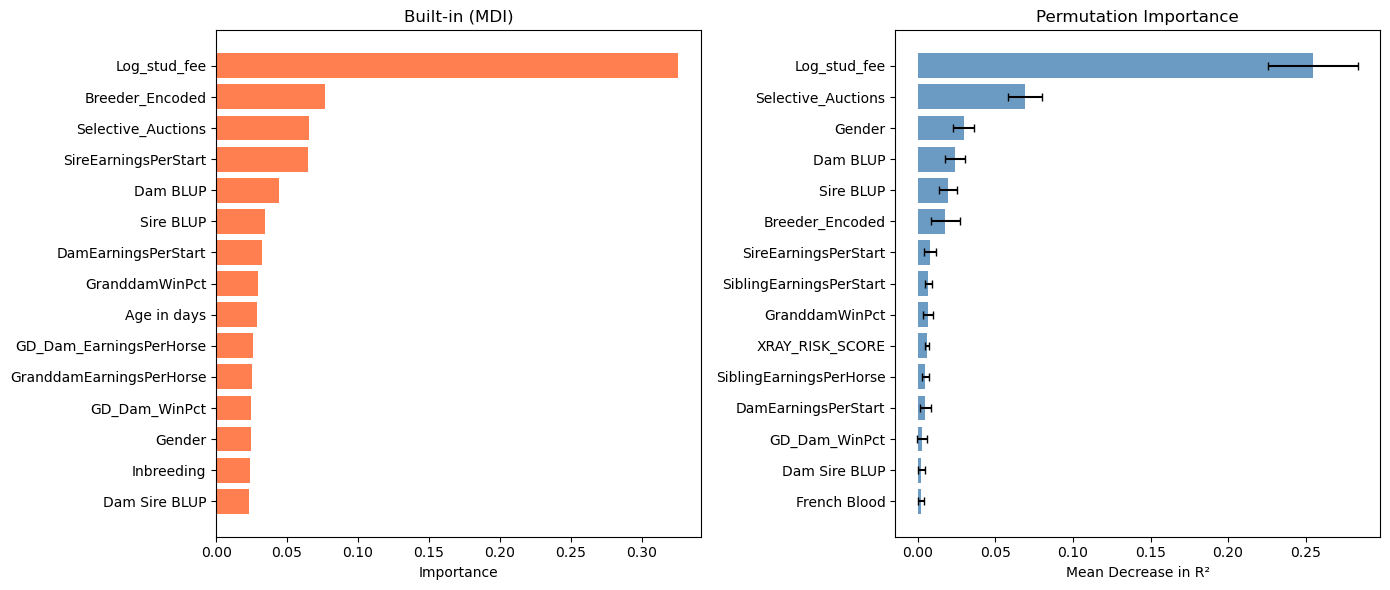

In [76]:
# =========================================================
# MDI AND PERMUTATION IMPORTANCE
# =========================================================

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

print("="*70)
print("PERMUTATION IMPORTANCE")
print("="*70)

print("\n[CALCULATING PERMUTATION IMPORTANCE]")
print("  Running 30 permutations per feature (this may take a minute)...")

# Calculate permutation importance on test set
perm_imp = permutation_importance(
    best_model, X_test.values, y_test.values,
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

# Create DataFrame for results
perm_imp_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance_Mean': perm_imp.importances_mean,
    'Importance_Std': perm_imp.importances_std
}).sort_values('Importance_Mean', ascending=False)

print("\n[TOP 15 FEATURES BY PERMUTATION IMPORTANCE]")
print(perm_imp_df.head(15).to_string(index=False))

# ---------------------------------------------------------
# Permutation importance plot with error bars
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

top_15 = perm_imp_df.head(15)
y_pos = range(len(top_15))

ax.barh(y_pos, top_15['Importance_Mean'].values,
        xerr=top_15['Importance_Std'].values,
        capsize=3, color='steelblue', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_15['Feature'].values)
ax.set_xlabel('Mean Decrease in R²')
ax.set_title('Permutation Importance (Test Set)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Compare MDI vs Permutation Importance
# ---------------------------------------------------------
print("\n[COMPARISON: MDI vs PERMUTATION IMPORTANCE]")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MDI (built-in)
sorted_idx_mdi = best_model.feature_importances_.argsort()[::-1][:15]
#axes[0].barh(range(15), model.feature_importances_[sorted_idx_mdi], color='coral')
axes[0].barh(range(15), best_model.feature_importances_[sorted_idx_mdi], color='coral')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([FEATURES[i] for i in sorted_idx_mdi])
axes[0].set_xlabel('Importance')
axes[0].set_title('Built-in (MDI)')
axes[0].invert_yaxis()
axes[0].barh(range(15), best_model.feature_importances_[sorted_idx_mdi], color='coral')

# Permutation (with error bars)
sorted_idx_perm = perm_imp.importances_mean.argsort()[::-1][:15]
axes[1].barh(range(15), perm_imp.importances_mean[sorted_idx_perm],
             xerr=perm_imp.importances_std[sorted_idx_perm],
             capsize=3, color='steelblue', alpha=0.8)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([FEATURES[i] for i in sorted_idx_perm])
axes[1].set_xlabel('Mean Decrease in R²')
axes[1].set_title('Permutation Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

fig.savefig('rf_mdi_vs_permutation.svg', dpi=300, bbox_inches='tight')
plt.show()
#plt.tight_layout()
#plt.show()

PARTIAL DEPENDENCE PLOTS

[PLOTTING PDPs FOR TOP 6 FEATURES]
  - Log_stud_fee
  - Selective_Auctions
  - Gender
  - Dam BLUP
  - Sire BLUP
  - Breeder_Encoded


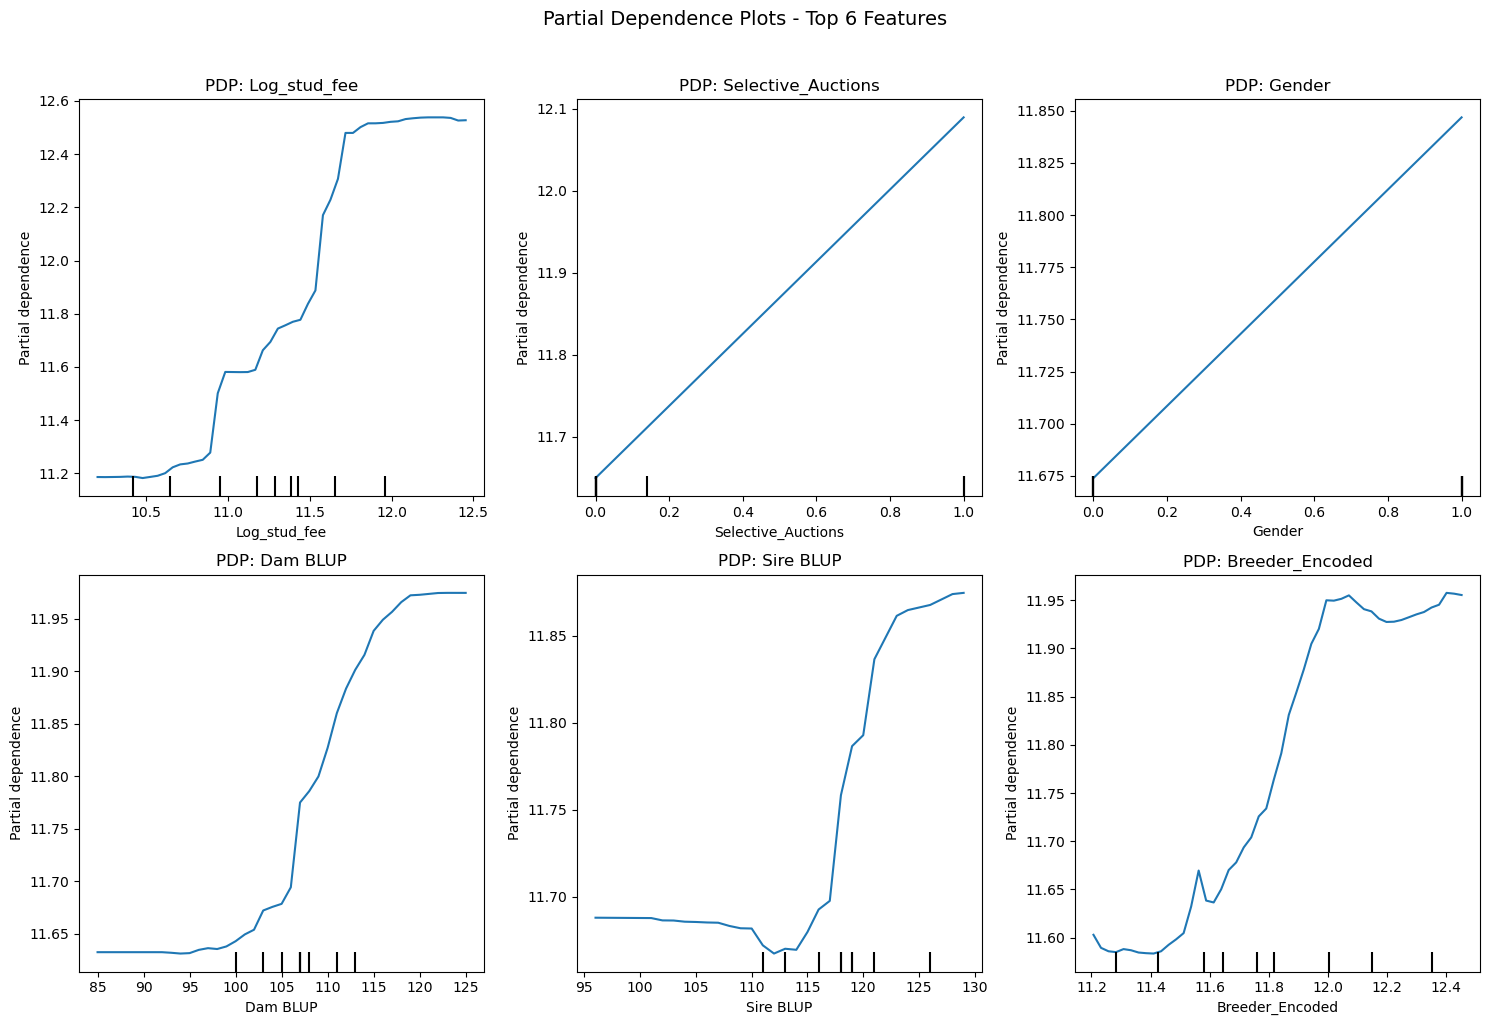

In [77]:
# =========================================================
# PARTIAL DEPENDENCE PLOTS
# =========================================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

print("="*70)
print("PARTIAL DEPENDENCE PLOTS")
print("="*70)

# Select top features for PDP (based on permutation importance)
top_features_idx = perm_imp.importances_mean.argsort()[::-1][:6]
top_feature_names = [FEATURES[i] for i in top_features_idx]

print(f"\n[PLOTTING PDPs FOR TOP 6 FEATURES]")
for f in top_feature_names:
    print(f"  - {f}")

# ---------------------------------------------------------
# Individual PDPs for top features
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feat_idx in enumerate(top_features_idx):
    PartialDependenceDisplay.from_estimator(
        best_model, X_train, features=[feat_idx],
        ax=axes[i], grid_resolution=50,
        feature_names=FEATURES
    )
    axes[i].set_title(f'PDP: {FEATURES[feat_idx]}')

plt.suptitle('Partial Dependence Plots - Top 6 Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


[2D INTERACTION PLOTS]
  Showing interaction between Log_stud_fee and other key features...


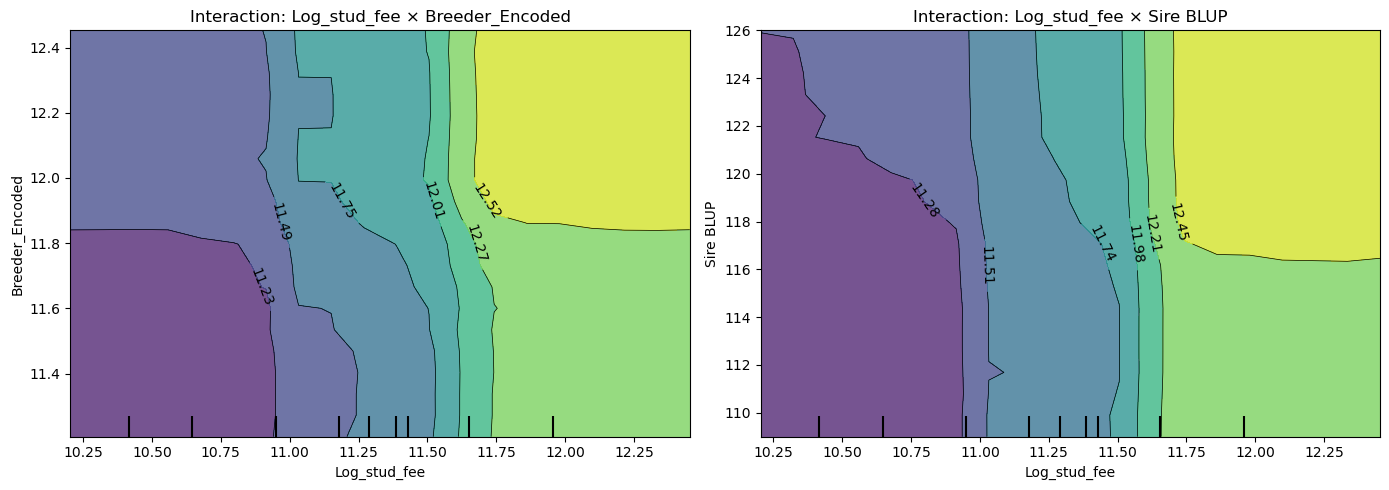

In [79]:
# ---------------------------------------------------------
# 2D PDP Interaction Plots
# ---------------------------------------------------------

print("\n[2D INTERACTION PLOTS]")
print("  Showing interaction between Log_stud_fee and other key features...")

# Find indices for specific features
stud_fee_idx = FEATURES.index('Log_stud_fee')
breeder_idx = FEATURES.index('Breeder_Encoded')

# Try to find other features that exist
interaction_pairs = []

# log_stud_fee vs Breeder_Encoded
interaction_pairs.append((stud_fee_idx, breeder_idx))

# log_stud_fee vs Sire BLUP (if exists)
if 'Sire BLUP' in FEATURES:
    sire_blup_idx = FEATURES.index('Sire BLUP')
    interaction_pairs.append((stud_fee_idx, sire_blup_idx))

fig, axes = plt.subplots(1, len(interaction_pairs), figsize=(7*len(interaction_pairs), 5))
if len(interaction_pairs) == 1:
    axes = [axes]

for i, pair in enumerate(interaction_pairs):
    PartialDependenceDisplay.from_estimator(
        best_model, X_train, features=[pair],
        ax=axes[i], grid_resolution=20,
        feature_names=FEATURES
    )
    axes[i].set_title(f'Interaction: {FEATURES[pair[0]]} × {FEATURES[pair[1]]}')

plt.tight_layout()
plt.show()

In [82]:
# =========================================================
# SHAP VALUES
# =========================================================

import shap

print("="*70)
print("SHAP ANALYSIS")
print("="*70)

print("\n[COMPUTING SHAP VALUES]")
print("  Creating TreeExplainer...")

# Create SHAP explainer for tree-based models
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
print("  Computing SHAP values for test set...")
shap_values = explainer.shap_values(X_test.values)

print(f"  SHAP values shape: {shap_values.shape}")
print("  Done!")

SHAP ANALYSIS

[COMPUTING SHAP VALUES]
  Creating TreeExplainer...
  Computing SHAP values for test set...
  SHAP values shape: (510, 30)
  Done!



[SHAP SUMMARY PLOT - BEESWARM]
  Shows feature importance AND direction of effect
  Red = high feature value, Blue = low feature value


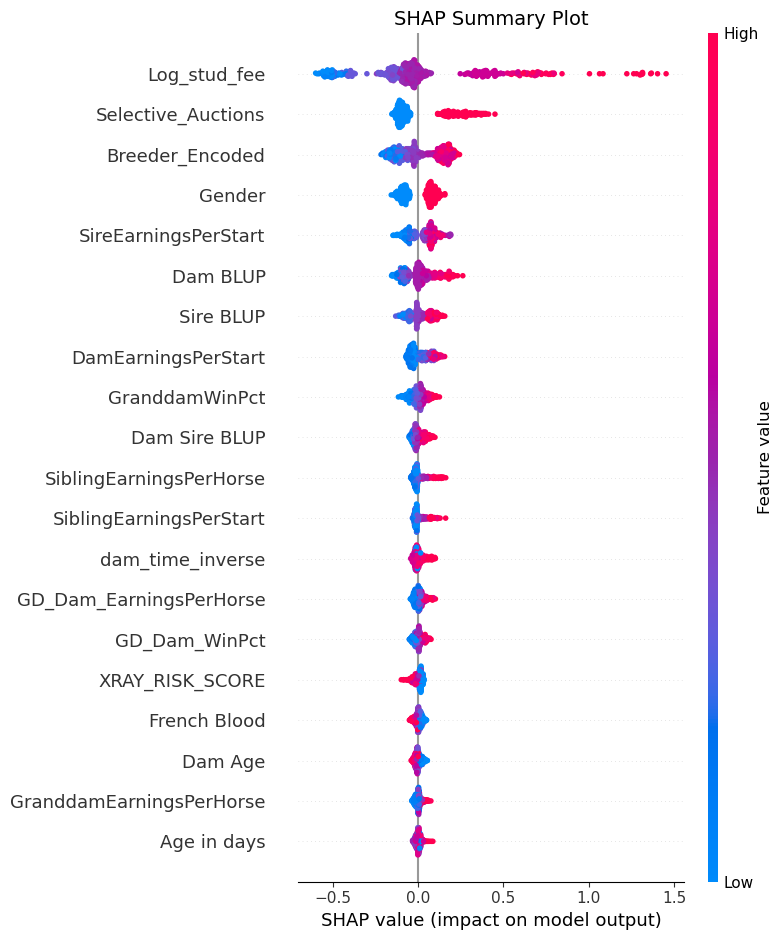

In [85]:
# ---------------------------------------------------------
# SHAP Summary Plot (Beeswarm)
# ---------------------------------------------------------

print("\n[SHAP SUMMARY PLOT - BEESWARM]")
print("  Shows feature importance AND direction of effect")
print("  Red = high feature value, Blue = low feature value")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Plot', fontsize=14)
plt.savefig('rf_SHAP_Beeswarm_plot.svg', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()


[SHAP FEATURE IMPORTANCE - BAR PLOT]


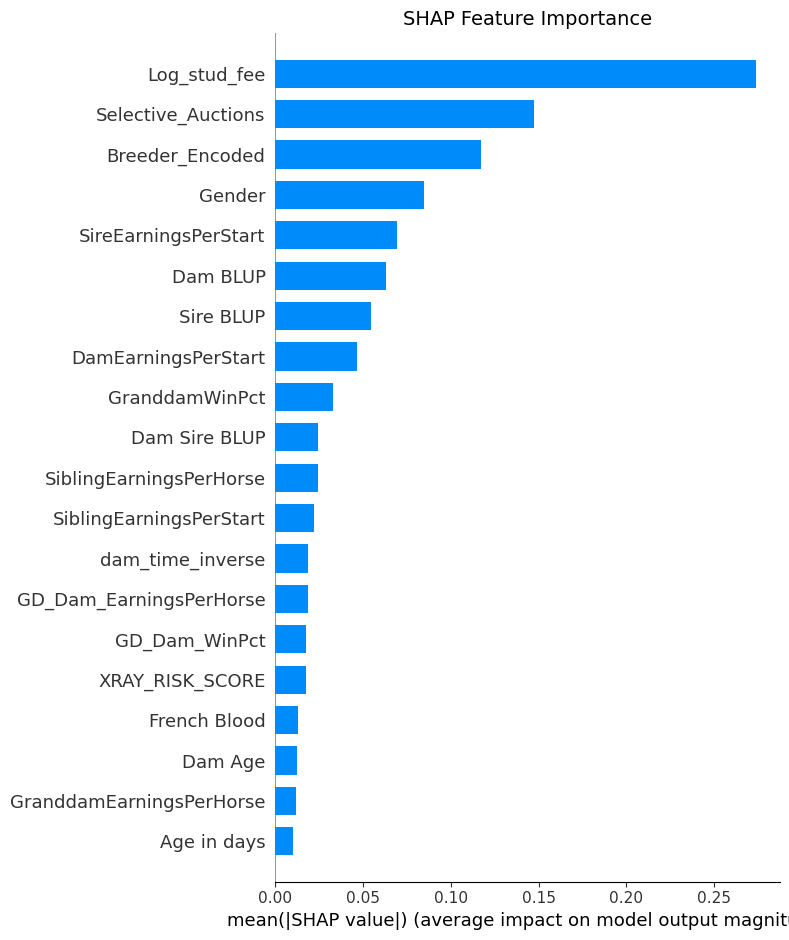

In [86]:
# ---------------------------------------------------------
# SHAP Bar Plot (Feature Importance)
# ---------------------------------------------------------

print("\n[SHAP FEATURE IMPORTANCE - BAR PLOT]")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, 
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()


[SHAP DEPENDENCE PLOTS]
  Similar to PDP but shows individual observations
  Color indicates interaction with auto-detected feature


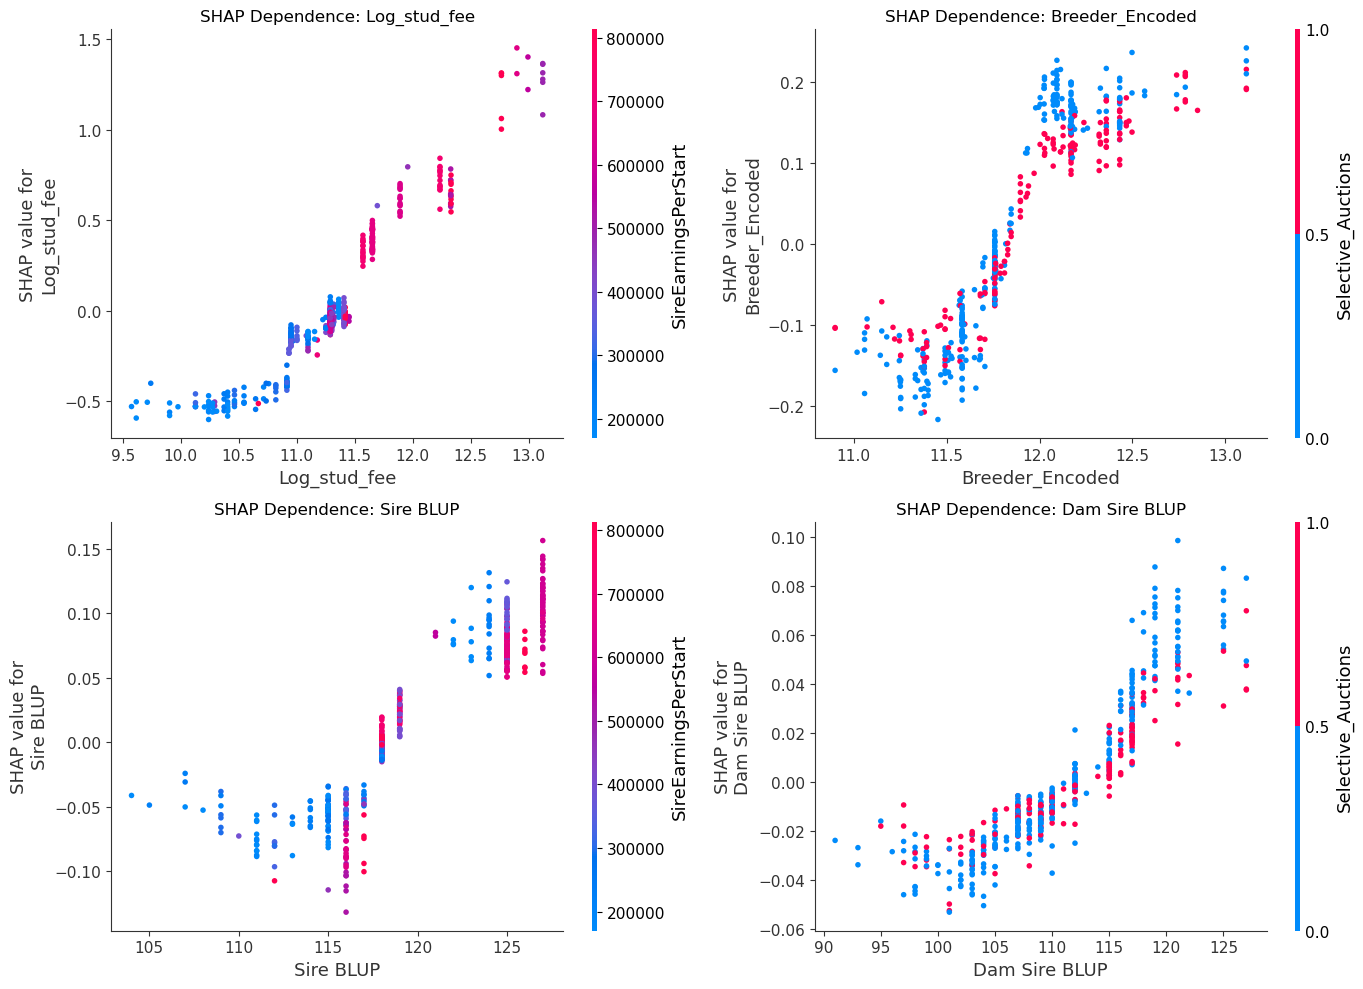

In [87]:
# ---------------------------------------------------------
# SHAP Dependence Plots for Key Features
# ---------------------------------------------------------

print("\n[SHAP DEPENDENCE PLOTS]")
print("  Similar to PDP but shows individual observations")
print("  Color indicates interaction with auto-detected feature")

# Key features to plot
key_features = ['Log_stud_fee', 'Breeder_Encoded']

# Add BLUP features if they exist
if 'Sire BLUP' in FEATURES:
    key_features.append('Sire BLUP')
if 'Dam Sire BLUP' in FEATURES:
    key_features.append('Dam Sire BLUP')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features[:4]):
    if feat in FEATURES:
        feat_idx = FEATURES.index(feat)
        plt.sca(axes[i])
        shap.dependence_plot(
            feat_idx, shap_values, X_test,
            feature_names=FEATURES,
            interaction_index='auto',
            ax=axes[i], show=False
        )
        axes[i].set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.show()


[SHAP WATERFALL - INDIVIDUAL PREDICTION EXPLANATION]
  Showing how features contribute to prediction for specific horses

  Highest Priced Horse (Test Set)
    Actual log(price): 14.914
    Predicted log(price): 13.675
    Actual price: 3,000,000 NOK
    Predicted price: 869,338 NOK


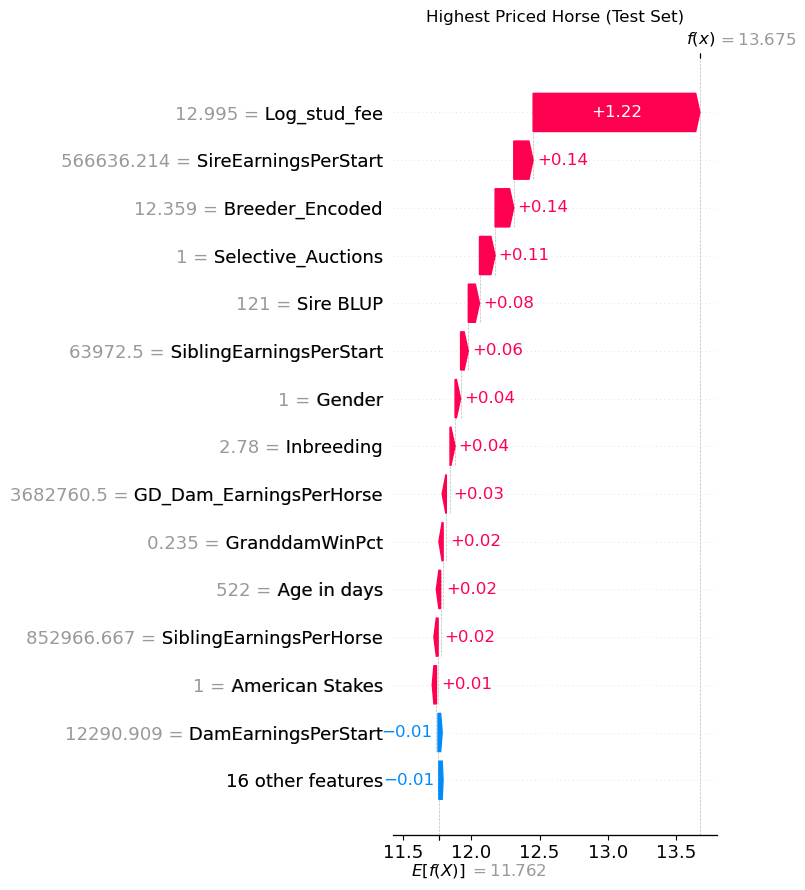


  Median Priced Horse (Test Set)
    Actual log(price): 11.918
    Predicted log(price): 12.281
    Actual price: 150,000 NOK
    Predicted price: 215,669 NOK


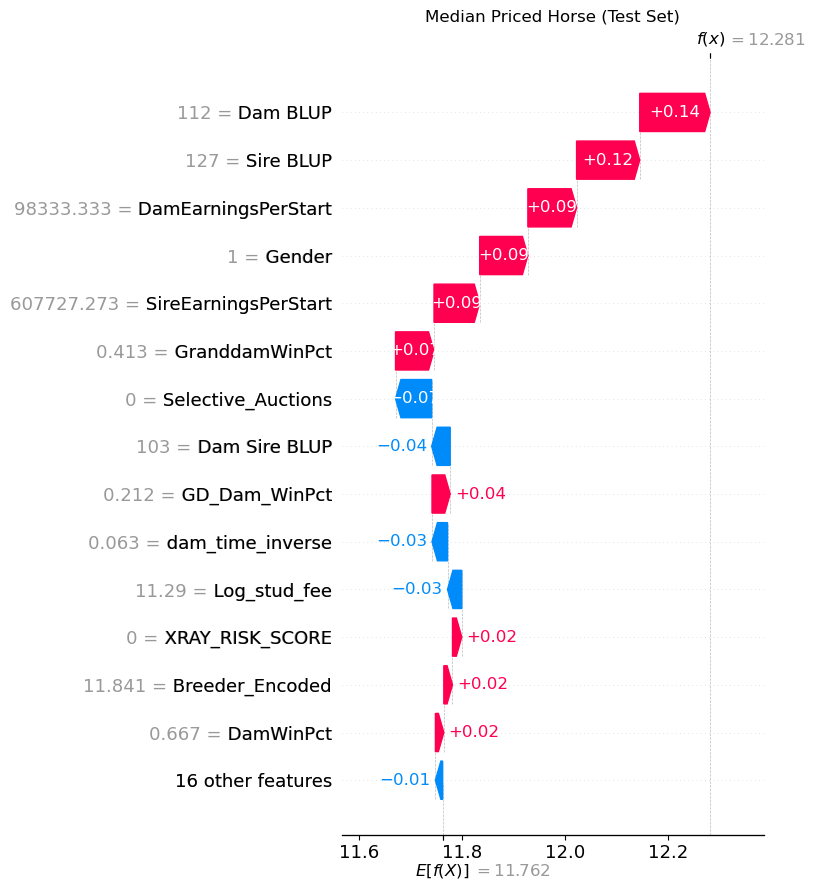


  Lowest Priced Horse (Test Set)
    Actual log(price): 10.127
    Predicted log(price): 11.205
    Actual price: 25,000 NOK
    Predicted price: 73,533 NOK


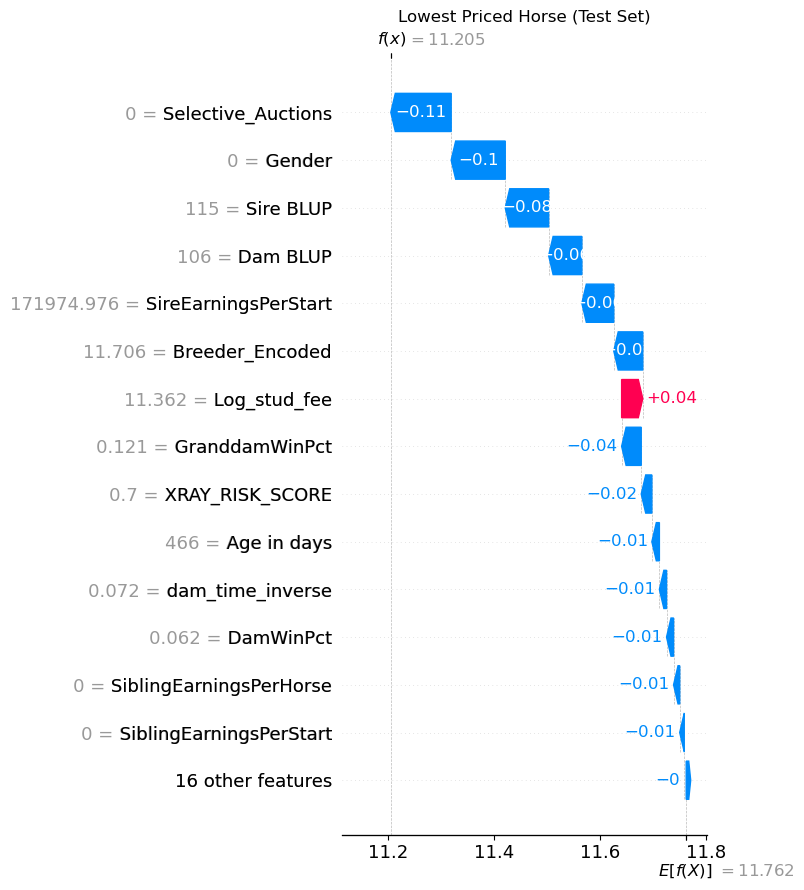

In [88]:
# ---------------------------------------------------------
# SHAP Waterfall for Individual Predictions
# ---------------------------------------------------------

print("\n[SHAP WATERFALL - INDIVIDUAL PREDICTION EXPLANATION]")
print("  Showing how features contribute to prediction for specific horses")

# Find interesting cases: highest priced, lowest priced, median
highest_idx = y_test.values.argmax()
lowest_idx = y_test.values.argmin()
median_idx = np.abs(y_test.values - np.median(y_test.values)).argmin()

cases = [
    ('Highest Priced Horse (Test Set)', highest_idx),
    ('Median Priced Horse (Test Set)', median_idx),
    ('Lowest Priced Horse (Test Set)', lowest_idx),
]

for title, idx in cases:
    print(f"\n  {title}")
    print(f"    Actual log(price): {y_test.values[idx]:.3f}")
   # print(f"    Predicted log(price): {pred_test[idx]:.3f}")
    print(f"    Predicted log(price): {pred_test_tuned[idx]:.3f}")  # ← pred_test_tuned
    print(f"    Actual price: {np.exp(y_test.values[idx]):,.0f} NOK")
 #   print(f"    Predicted price: {np.exp(pred_test[idx]):,.0f} NOK")
    print(f"    Predicted price: {np.exp(pred_test_tuned[idx]):,.0f} NOK")  # ← pred_test_tuned

  
    # Create SHAP explanation object
    shap_exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.values[idx],
        feature_names=FEATURES
    )
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, show=False, max_display=15)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [89]:
# =========================================================
# IMPORTANCE COMPARISON SUMMARY
# =========================================================

print("="*70)
print("IMPORTANCE COMPARISON SUMMARY")
print("="*70)

# Calculate mean absolute SHAP values per feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': FEATURES,
    'MDI (Built-in)': best_model.feature_importances_,
    'Permutation': perm_imp.importances_mean,
    'SHAP': shap_importance
})

# Normalize each to 0-1 scale for comparison
for col in ['MDI (Built-in)', 'Permutation', 'SHAP']:
    comparison_df[f'{col}_Rank'] = comparison_df[col].rank(ascending=False).astype(int)

# Sort by average rank
comparison_df['Avg_Rank'] = comparison_df[['MDI (Built-in)_Rank', 'Permutation_Rank', 'SHAP_Rank']].mean(axis=1)
comparison_df = comparison_df.sort_values('Avg_Rank')

print("\n[FEATURE RANKING BY DIFFERENT METHODS]")
print(comparison_df[['Feature', 'MDI (Built-in)_Rank', 'Permutation_Rank', 'SHAP_Rank', 'Avg_Rank']].head(15).to_string(index=False))

# Correlation between methods
print("\n[CORRELATION BETWEEN IMPORTANCE METHODS]")
print(f"  MDI vs Permutation: {comparison_df['MDI (Built-in)'].corr(comparison_df['Permutation']):.3f}")
print(f"  MDI vs SHAP:        {comparison_df['MDI (Built-in)'].corr(comparison_df['SHAP']):.3f}")
print(f"  Permutation vs SHAP: {comparison_df['Permutation'].corr(comparison_df['SHAP']):.3f}")

IMPORTANCE COMPARISON SUMMARY

[FEATURE RANKING BY DIFFERENT METHODS]
                Feature  MDI (Built-in)_Rank  Permutation_Rank  SHAP_Rank  Avg_Rank
           Log_stud_fee                    1                 1          1  1.000000
     Selective_Auctions                    3                 2          2  2.333333
        Breeder_Encoded                    2                 6          3  3.666667
               Dam BLUP                    5                 4          6  5.000000
   SireEarningsPerStart                    4                 7          5  5.333333
              Sire BLUP                    6                 5          7  6.000000
                 Gender                   13                 3          4  6.666667
         GranddamWinPct                    8                 9          9  8.666667
    DamEarningsPerStart                    7                12          8  9.000000
          Dam Sire BLUP                   15                14         10 13.000000
Siblin

In [90]:
# =========================================================
# EXPORT IMPORTANCE COMPARISON TO WORD
# =========================================================

from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create Word document
doc = Document()

# Add title
title = doc.add_heading('Feature Importance Comparison — Random Forest', level=2)

# ---------------------------------------------------------
# Table 1: Feature Rankings
# ---------------------------------------------------------
doc.add_paragraph('Table X: Feature Ranking by Different Importance Methods')

# Prepare data (top 15 features)
table_data = comparison_df[['Feature', 'MDI (Built-in)_Rank', 'Permutation_Rank', 'SHAP_Rank', 'Avg_Rank']].head(15)

# Create table
table = doc.add_table(rows=1, cols=5)
table.style = 'Table Grid'

# Header row
header_cells = table.rows[0].cells
headers = ['Feature', 'MDI Rank', 'Permutation Rank', 'SHAP Rank', 'Avg Rank']
for i, header in enumerate(headers):
    header_cells[i].text = header
    header_cells[i].paragraphs[0].runs[0].bold = True
    header_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Data rows
for _, row in table_data.iterrows():
    row_cells = table.add_row().cells
    row_cells[0].text = str(row['Feature'])
    row_cells[1].text = str(int(row['MDI (Built-in)_Rank']))
    row_cells[2].text = str(int(row['Permutation_Rank']))
    row_cells[3].text = str(int(row['SHAP_Rank']))
    row_cells[4].text = f"{row['Avg_Rank']:.1f}"
    
    # Center align numeric columns
    for i in range(1, 5):
        row_cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# Add spacing
doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Correlation Between Methods
# ---------------------------------------------------------
doc.add_paragraph('Table X: Correlation Between Importance Methods')

corr_table = doc.add_table(rows=4, cols=2)
corr_table.style = 'Table Grid'

# Header
corr_table.rows[0].cells[0].text = 'Method Pair'
corr_table.rows[0].cells[1].text = 'Correlation'
corr_table.rows[0].cells[0].paragraphs[0].runs[0].bold = True
corr_table.rows[0].cells[1].paragraphs[0].runs[0].bold = True

# Data
corr_data = [
    ('MDI vs Permutation', comparison_df['MDI (Built-in)'].corr(comparison_df['Permutation'])),
    ('MDI vs SHAP', comparison_df['MDI (Built-in)'].corr(comparison_df['SHAP'])),
    ('Permutation vs SHAP', comparison_df['Permutation'].corr(comparison_df['SHAP']))
]

for i, (pair, corr) in enumerate(corr_data, start=1):
    corr_table.rows[i].cells[0].text = pair
    corr_table.rows[i].cells[1].text = f"{corr:.3f}"
    corr_table.rows[i].cells[1].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

# ---------------------------------------------------------
# Save document
# ---------------------------------------------------------
output_path = 'RF_importance_comparison.docx'
doc.save(output_path)
print(f"✓ Saved: {output_path}")

✓ Saved: RF_importance_comparison.docx


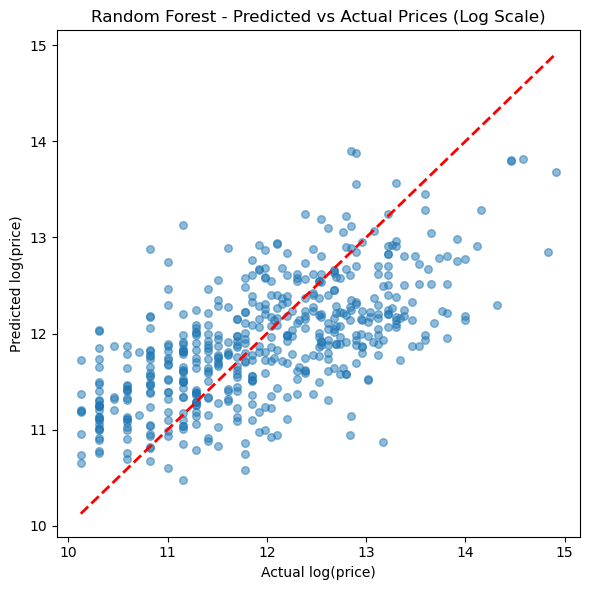

In [91]:
# =========================================================
# PREDICTED VS ACTUAL PLOT (TUNED MODEL)
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(y_test, pred_test_tuned, alpha=0.5, s=30)

# 45-degree reference line
min_val = min(y_test.min(), pred_test_tuned.min())
max_val = max(y_test.max(), pred_test_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual log(price)")
plt.ylabel("Predicted log(price)")
plt.title("Random Forest - Predicted vs Actual Prices (Log Scale)")

plt.tight_layout()
plt.savefig('Random Forst.svg', dpi=150, bbox_inches='tight')
plt.show()

TOP-DECILE ACCURACY ANALYSIS (TUNED MODEL)

[TOP-DECILE THRESHOLDS]
  Training (90th percentile):      480,000 NOK
  Test (90th percentile):          550,000 NOK

[TOP-DECILE COUNTS]
  Training: 119 actual, 107 predicted
  Test:     62 actual, 21 predicted

[TOP-DECILE CLASSIFICATION METRICS]

  Training:
    Precision: 0.869  (Of predicted top-10%, 86.9% are actually top-10%)
    Recall:    0.782  (Of actual top-10%, 78.2% were identified)
    F1-Score:  0.823

  Test:
    Precision: 0.476  (Of predicted top-10%, 47.6% are actually top-10%)
    Recall:    0.161  (Of actual top-10%, 16.1% were identified)
    F1-Score:  0.241

[TOP-DECILE CONFUSION MATRIX - Test Set]

                    Predicted
                 Not Top-10%  Top-10%
Actual Not Top           437        11
Actual Top-10%            52        10

  True Positives (TP):    10  (Correctly identified as top-10%)
  False Positives (FP):   11  (Predicted top-10% but not)
  True Negatives (TN):   437  (Correctly identified as

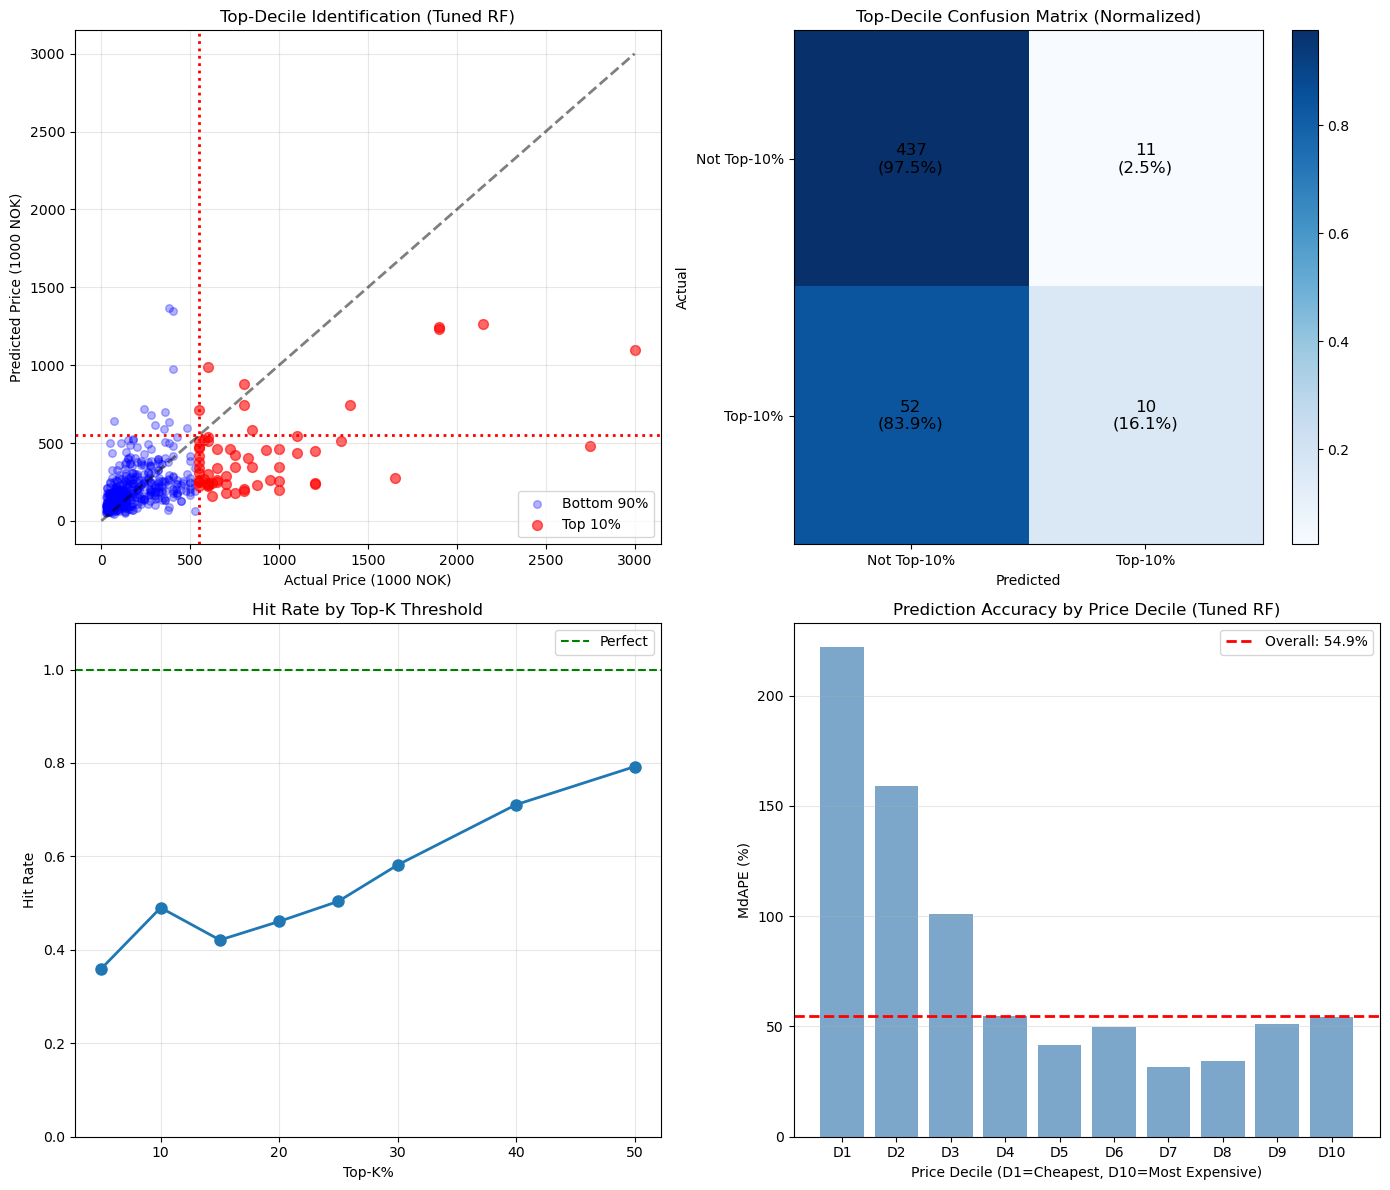

  ✓ Saved: rf_tuned_top_decile_analysis.png

[EXPORTING SUMMARY]
  ✓ Saved: rf_tuned_top_decile_metrics.xlsx

TOP-DECILE ANALYSIS COMPLETE


In [92]:
# =========================================================
# TOP-DECILE ACCURACY METRICS (TUNED MODEL)
# =========================================================

import numpy as np
import pandas as pd

print("="*70)
print("TOP-DECILE ACCURACY ANALYSIS (TUNED MODEL)")
print("="*70)

# Calculate train price predictions for tuned model (if not already defined)
#pred_train_price_tuned = np.exp(pred_train_tuned + sigma2_tuned/2)

# =========================================================
# 1. DEFINE TOP-DECILE THRESHOLDS
# =========================================================

# Training data
top_decile_threshold_train = np.percentile(y_train_price, 90)
print(f"\n[TOP-DECILE THRESHOLDS]")
print(f"  Training (90th percentile): {top_decile_threshold_train:>12,.0f} NOK")

# Test data
top_decile_threshold_test = np.percentile(y_test_price, 90)
print(f"  Test (90th percentile):     {top_decile_threshold_test:>12,.0f} NOK")

# =========================================================
# 2. IDENTIFY TOP-DECILE HORSES
# =========================================================

# Actual top-decile (ground truth)
actual_top_decile_train = y_train_price >= top_decile_threshold_train
actual_top_decile_test = y_test_price >= top_decile_threshold_test

# Predicted top-decile (based on tuned model)
pred_top_decile_train = pred_train_price_tuned >= top_decile_threshold_train
pred_top_decile_test = pred_test_price_tuned >= top_decile_threshold_test

print(f"\n[TOP-DECILE COUNTS]")
print(f"  Training: {actual_top_decile_train.sum()} actual, {pred_top_decile_train.sum()} predicted")
print(f"  Test:     {actual_top_decile_test.sum()} actual, {pred_top_decile_test.sum()} predicted")

# =========================================================
# 3. PRECISION AND RECALL
# =========================================================

from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\n[TOP-DECILE CLASSIFICATION METRICS]")

# Training
precision_train = precision_score(actual_top_decile_train, pred_top_decile_train)
recall_train = recall_score(actual_top_decile_train, pred_top_decile_train)
f1_train = f1_score(actual_top_decile_train, pred_top_decile_train)

print(f"\n  Training:")
print(f"    Precision: {precision_train:.3f}  (Of predicted top-10%, {precision_train*100:.1f}% are actually top-10%)")
print(f"    Recall:    {recall_train:.3f}  (Of actual top-10%, {recall_train*100:.1f}% were identified)")
print(f"    F1-Score:  {f1_train:.3f}")

# Test
precision_test = precision_score(actual_top_decile_test, pred_top_decile_test)
recall_test = recall_score(actual_top_decile_test, pred_top_decile_test)
f1_test = f1_score(actual_top_decile_test, pred_top_decile_test)

print(f"\n  Test:")
print(f"    Precision: {precision_test:.3f}  (Of predicted top-10%, {precision_test*100:.1f}% are actually top-10%)")
print(f"    Recall:    {recall_test:.3f}  (Of actual top-10%, {recall_test*100:.1f}% were identified)")
print(f"    F1-Score:  {f1_test:.3f}")

# =========================================================
# 4. CONFUSION MATRIX FOR TOP-DECILE
# =========================================================

from sklearn.metrics import confusion_matrix

print(f"\n[TOP-DECILE CONFUSION MATRIX - Test Set]")

cm = confusion_matrix(actual_top_decile_test, pred_top_decile_test)

print(f"\n                    Predicted")
print(f"                 Not Top-10%  Top-10%")
print(f"Actual Not Top   {cm[0,0]:>11}  {cm[0,1]:>8}")
print(f"Actual Top-10%   {cm[1,0]:>11}  {cm[1,1]:>8}")

# Calculate rates
tn, fp, fn, tp = cm.ravel()
print(f"\n  True Positives (TP):  {tp:>4}  (Correctly identified as top-10%)")
print(f"  False Positives (FP): {fp:>4}  (Predicted top-10% but not)")
print(f"  True Negatives (TN):  {tn:>4}  (Correctly identified as not top-10%)")
print(f"  False Negatives (FN): {fn:>4}  (Missed actual top-10%)")

# =========================================================
# 5. TOP-DECILE SPECIFIC ERROR METRICS
# =========================================================

print(f"\n[ERROR METRICS FOR TOP-DECILE HORSES]")

# Test set - only top-decile horses
top_decile_mask_test = actual_top_decile_test
if top_decile_mask_test.sum() > 0:
    
    # Price errors for top-decile
    actual_top = y_test_price[top_decile_mask_test]
    pred_top = pred_test_price_tuned[top_decile_mask_test]
    
    mape_top = np.mean(np.abs((actual_top - pred_top) / actual_top)) * 100
    mdape_top = np.median(np.abs((actual_top - pred_top) / actual_top)) * 100
    rmse_top = np.sqrt(np.mean((actual_top - pred_top)**2))
    mae_top = np.mean(np.abs(actual_top - pred_top))
    mean_error_top = np.mean(actual_top - pred_top)
    
    print(f"\n  Test Set - Top-Decile Only (n={top_decile_mask_test.sum()}):")
    print(f"    MAPE:        {mape_top:.1f}%")
    print(f"    MdAPE:       {mdape_top:.1f}%")
    print(f"    RMSE:        {rmse_top:,.0f} NOK")
    print(f"    MAE:         {mae_top:,.0f} NOK")
    print(f"    Mean Error:  {mean_error_top:+,.0f} NOK")
    
    # Compare to overall test set
    mape_overall = np.mean(np.abs((y_test_price - pred_test_price_tuned) / y_test_price)) * 100
    mdape_overall = np.median(np.abs((y_test_price - pred_test_price_tuned) / y_test_price)) * 100
    
    print(f"\n  Comparison to Overall Test Set:")
    print(f"    Top-10% MdAPE:  {mdape_top:.1f}%")
    print(f"    Overall MdAPE:  {mdape_overall:.1f}%")
    print(f"    Difference:     {mdape_top - mdape_overall:+.1f}%")
    
    if mdape_top < mdape_overall:
        print(f"    ✓ Model is MORE accurate for expensive horses")
    else:
        print(f"    ⚠ Model is LESS accurate for expensive horses")

# =========================================================
# 6. HIT RATE ANALYSIS
# =========================================================

print(f"\n[HIT RATE ANALYSIS]")
print("  (If you bid on predicted top-10%, what do you get?)")

# Get top N predictions
n_top = actual_top_decile_test.sum()  # Number of actual top-decile horses

# Sort by predicted price
test_indices = np.argsort(pred_test_price_tuned)[::-1]  # Descending order
top_n_predicted = test_indices[:n_top]

# How many are actually in top-decile?
#hits = actual_top_decile_test.iloc[top_n_predicted].sum()
hits = actual_top_decile_test[top_n_predicted].sum()
hit_rate = hits / n_top

print(f"\n  Strategy: Bid on top {n_top} horses (by predicted price)")
print(f"  Result:   {hits} out of {n_top} are actually top-10%")
print(f"  Hit Rate: {hit_rate:.1%}")

# Average price of horses we'd bid on
#avg_actual_price_bid = y_test_price.iloc[top_n_predicted].mean()
avg_actual_price_bid = y_test_price[top_n_predicted].mean()
avg_pred_price_bid = pred_test_price_tuned[top_n_predicted].mean()


print(f"\n  Horses we'd bid on:")
print(f"    Avg predicted price: {avg_pred_price_bid:>12,.0f} NOK")
print(f"    Avg actual price:    {avg_actual_price_bid:>12,.0f} NOK")
print(f"    Difference:          {avg_actual_price_bid - avg_pred_price_bid:>12,.0f} NOK")

# =========================================================
# 7. RANK CORRELATION
# =========================================================

from scipy.stats import spearmanr, kendalltau

print(f"\n[RANK CORRELATION]")
print("  (How well does model rank horses from cheap to expensive?)")

spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price_tuned)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price_tuned)

print(f"\n  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")
print(f"  Kendall Tau:          {kendall_corr:.4f} (p={kendall_p:.4e})")

if spearman_corr > 0.7:
    print(f"  ✓ Excellent ranking ability")
elif spearman_corr > 0.5:
    print(f"  ~ Good ranking ability")
else:
    print(f"  ⚠ Moderate ranking ability")

# =========================================================
# 8. TOP-K ACCURACY (VARYING K)
# =========================================================

print(f"\n[TOP-K ACCURACY FOR DIFFERENT K VALUES]")
print(f"{'Top-K':<10} {'Actual in K':<15} {'Hit Rate':<12} {'Precision'}")
print(f"{'-'*10} {'-'*15} {'-'*12} {'-'*12}")

for k_pct in [5, 10, 15, 20, 25]:
    k = int(len(y_test_price) * k_pct / 100)
    
    # Get top-k by prediction
    top_k_indices = np.argsort(pred_test_price_tuned)[::-1][:k]
    
    # Threshold for actual top-k
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
    
    # How many of predicted top-k are actually top-k?
   # hits_k = actual_top_k.iloc[top_k_indices].sum()
    hits_k = actual_top_k[top_k_indices].sum()
    hit_rate_k = hits_k / k
    
    print(f"Top-{k_pct:>2}%    {hits_k:>5}/{k:<7}    {hit_rate_k:>11.1%}    {hit_rate_k:.3f}")

# =========================================================
# 9. VISUALIZATION
# =========================================================

print(f"\n[CREATING VISUALIZATIONS]")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Scatter with top-decile highlighted
ax1 = axes[0, 0]
# Regular horses
mask_regular = ~actual_top_decile_test
ax1.scatter(y_test_price[mask_regular]/1000, 
            pred_test_price_tuned[mask_regular]/1000,
            alpha=0.3, s=30, label='Bottom 90%', color='blue')
# Top-decile horses
ax1.scatter(y_test_price[actual_top_decile_test]/1000,
            pred_test_price_tuned[actual_top_decile_test]/1000,
            alpha=0.6, s=50, label='Top 10%', color='red')
# Perfect prediction line
max_price = y_test_price.max() / 1000
ax1.plot([0, max_price], [0, max_price], 'k--', lw=2, alpha=0.5)
# Threshold lines
ax1.axvline(x=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.axhline(y=top_decile_threshold_test/1000, color='red', linestyle=':', lw=2)
ax1.set_xlabel('Actual Price (1000 NOK)')
ax1.set_ylabel('Predicted Price (1000 NOK)')
ax1.set_title('Top-Decile Identification (Tuned RF)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix Heatmap
ax2 = axes[0, 1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax2.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_yticklabels(['Not Top-10%', 'Top-10%'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Top-Decile Confusion Matrix (Normalized)')
# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                       ha="center", va="center", color="black", fontsize=12)
plt.colorbar(im, ax=ax2)

# Plot 3: Top-K Accuracy Curve
ax3 = axes[1, 0]
k_values = [5, 10, 15, 20, 25, 30, 40, 50]
hit_rates = []
for k_pct in k_values:
    k = int(len(y_test_price) * k_pct / 100)
    top_k_indices = np.argsort(pred_test_price_tuned)[::-1][:k]
    threshold_k = np.percentile(y_test_price, 100 - k_pct)
    actual_top_k = y_test_price >= threshold_k
  #  hits_k = actual_top_k.iloc[top_k_indices].sum()
    hits_k = actual_top_k[top_k_indices].sum()
    hit_rates.append(hits_k / k)

ax3.plot(k_values, hit_rates, marker='o', linewidth=2, markersize=8)
ax3.axhline(y=1.0, color='green', linestyle='--', label='Perfect')
ax3.set_xlabel('Top-K%')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Hit Rate by Top-K Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.1)

# Plot 4: Error by Price Decile
ax4 = axes[1, 1]
decile_labels = []
decile_mdapes = []
for i in range(10):
    lower = np.percentile(y_test_price, i*10)
    upper = np.percentile(y_test_price, (i+1)*10)
    mask = (y_test_price >= lower) & (y_test_price < upper)
    if mask.sum() > 0:
        apes = np.abs((y_test_price[mask] - pred_test_price_tuned[mask]) / y_test_price[mask]) * 100
        decile_mdapes.append(np.median(apes))
        decile_labels.append(f'D{i+1}')

ax4.bar(range(len(decile_labels)), decile_mdapes, color='steelblue', alpha=0.7)
ax4.axhline(y=mdape_overall, color='red', linestyle='--', lw=2, label=f'Overall: {mdape_overall:.1f}%')
ax4.set_xlabel('Price Decile (D1=Cheapest, D10=Most Expensive)')
ax4.set_ylabel('MdAPE (%)')
ax4.set_title('Prediction Accuracy by Price Decile (Tuned RF)')
ax4.set_xticks(range(len(decile_labels)))
ax4.set_xticklabels(decile_labels)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rf_tuned_top_decile_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("  ✓ Saved: rf_tuned_top_decile_analysis.png")

# =========================================================
# 10. EXPORT SUMMARY
# =========================================================

print(f"\n[EXPORTING SUMMARY]")

top_decile_summary = pd.DataFrame({
    'Metric': [
        'Top-Decile Threshold',
        'Precision',
        'Recall',
        'F1-Score',
        'Hit Rate',
        'Top-Decile MdAPE',
        'Overall MdAPE',
        'Spearman Correlation',
    ],
    'Test': [
        f'{top_decile_threshold_test:,.0f} NOK',
        f'{precision_test:.3f}',
        f'{recall_test:.3f}',
        f'{f1_test:.3f}',
        f'{hit_rate:.1%}',
        f'{mdape_top:.1f}%',
        f'{mdape_overall:.1f}%',
        f'{spearman_corr:.4f}',
    ]
})

top_decile_summary.to_excel('rf_tuned_top_decile_metrics.xlsx', index=False)
print("  ✓ Saved: rf_tuned_top_decile_metrics.xlsx")

print("\n" + "="*70)
print("TOP-DECILE ANALYSIS COMPLETE")
print("="*70)

RESIDUAL ANALYSIS (TUNED MODEL)

[LOG SCALE RESIDUALS]
  Mean:     -0.0538
  Median:   -0.0150
  Std:      0.7628
  Skewness: -0.1343
  Kurtosis: -0.4012

[PRICE SCALE RESIDUALS]
  Mean:     -27,355 NOK
  Median:   +28,562 NOK

[INTERPRETATION]
  Skewness (-0.13): Approximately symmetric ✓
  Kurtosis (-0.40): Near normal tails ✓


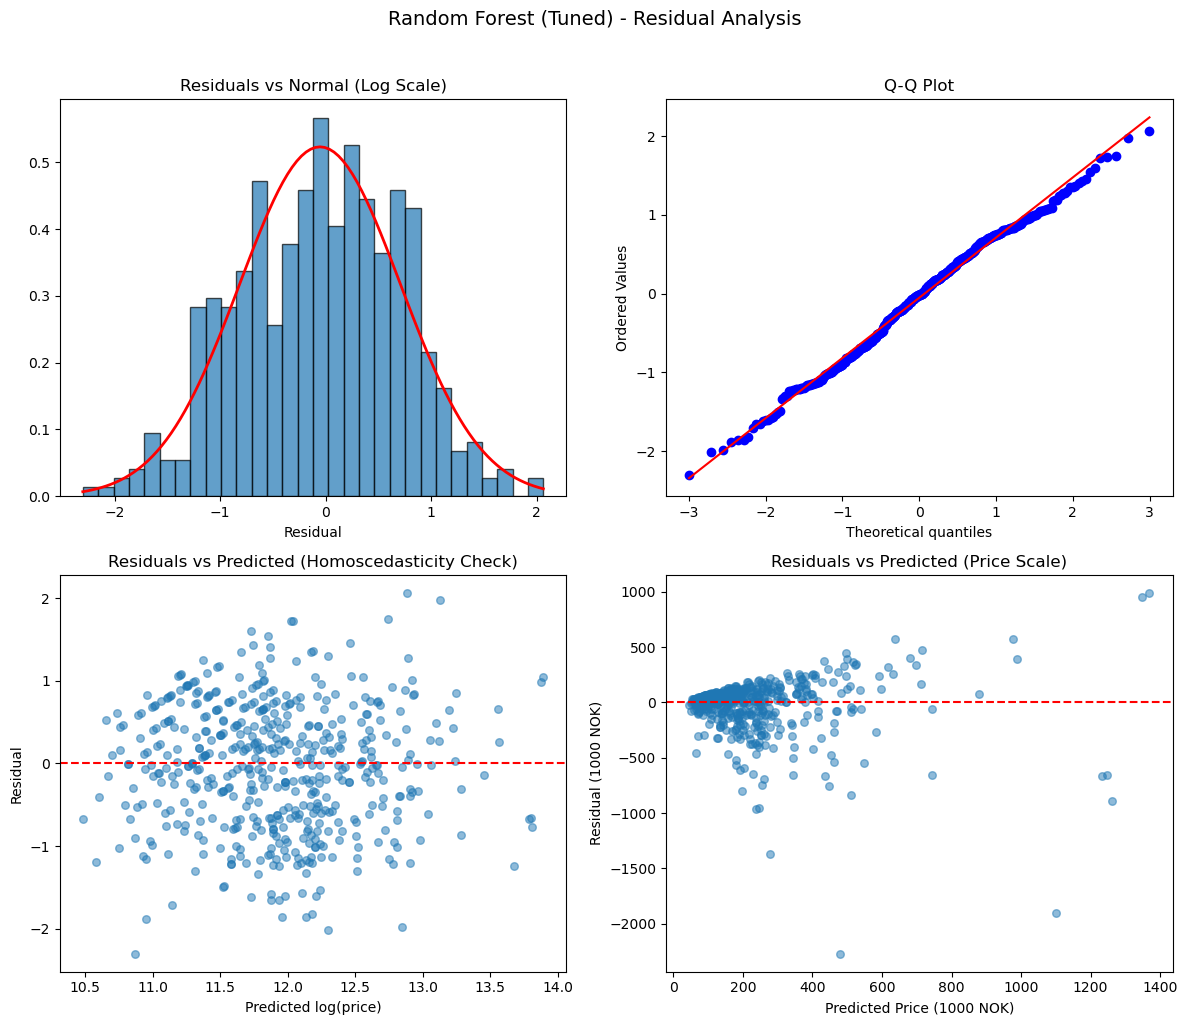


✓ Saved: rf_tuned_residual_analysis.svg


In [127]:
# =========================================================
# RESIDUAL ANALYSIS (TUNED MODEL)
# =========================================================

from scipy import stats

print("="*70)
print("RESIDUAL ANALYSIS (TUNED MODEL)")
print("="*70)

residuals_log = pred_test_tuned - y_test.values 
residuals_price = pred_test_price_tuned - y_test_price

# Descriptive statistics
print(f"\n[LOG SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_log):.4f}")
print(f"  Median:   {np.median(residuals_log):.4f}")
print(f"  Std:      {np.std(residuals_log):.4f}")
print(f"  Skewness: {stats.skew(residuals_log):.4f}")
print(f"  Kurtosis: {stats.kurtosis(residuals_log):.4f}")

print(f"\n[PRICE SCALE RESIDUALS]")
print(f"  Mean:     {np.mean(residuals_price):+,.0f} NOK")
print(f"  Median:   {np.median(residuals_price):+,.0f} NOK")

# Normality tests (Not applicable for Random forest, so commented out) 
#print(f"\n[NORMALITY TESTS - LOG SCALE]")
#if len(residuals_log) <= 5000:
#    stat_sw, p_sw = stats.shapiro(residuals_log)
#    result_sw = "Normal ✓" if p_sw > 0.05 else "Not Normal ✗"
#    print(f"  Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f} → {result_sw}")

#stat_jb, p_jb = stats.jarque_bera(residuals_log)
#result_jb = "Normal ✓" if p_jb > 0.05 else "Not Normal ✗"
#print(f"  Jarque-Bera: JB={stat_jb:.4f}, p={p_jb:.4f} → {result_jb}")

# Interpretation
skewness = stats.skew(residuals_log)
kurtosis = stats.kurtosis(residuals_log)

print(f"\n[INTERPRETATION]")
if abs(skewness) < 0.5:
    print(f"  Skewness ({skewness:.2f}): Approximately symmetric ✓")
else:
    print(f"  Skewness ({skewness:.2f}): {'Right' if skewness > 0 else 'Left'}-skewed")

if abs(kurtosis) < 1:
    print(f"  Kurtosis ({kurtosis:.2f}): Near normal tails ✓")
else:
    print(f"  Kurtosis ({kurtosis:.2f}): {'Heavy' if kurtosis > 0 else 'Light'} tails")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram
ax1 = axes[0, 0]
ax1.hist(residuals_log, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(residuals_log.min(), residuals_log.max(), 100)
ax1.plot(x, stats.norm.pdf(x, np.mean(residuals_log), np.std(residuals_log)), 'r-', lw=2)
ax1.set_title('Residuals vs Normal (Log Scale)')
ax1.set_xlabel('Residual')

# Q-Q plot
ax2 = axes[0, 1]
stats.probplot(residuals_log, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot')

# Residuals vs Predicted
ax3 = axes[1, 0]
ax3.scatter(pred_test_tuned, residuals_log, alpha=0.5, s=30)
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Predicted log(price)')
ax3.set_ylabel('Residual')
ax3.set_title('Residuals vs Predicted (Homoscedasticity Check)')

# Residuals vs Fitted (price scale)
ax4 = axes[1, 1]
ax4.scatter(pred_test_price_tuned/1000, residuals_price/1000, alpha=0.5, s=30)
ax4.axhline(y=0, color='r', linestyle='--')
ax4.set_xlabel('Predicted Price (1000 NOK)')
ax4.set_ylabel('Residual (1000 NOK)')
ax4.set_title('Residuals vs Predicted (Price Scale)')

plt.suptitle('Random Forest (Tuned) - Residual Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rf_tuned_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: rf_tuned_residual_analysis.svg")

In [94]:
# =========================================================
# OUT-OF-FOLD (OOF) DIAGNOSTICS - Random Forest
# =========================================================

print("="*70)
print("OUT-OF-FOLD (OOF) DIAGNOSTICS - Random Forest")
print("="*70)

from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.ensemble import RandomForestRegressor

# ---------------------------------------------------------
# Generate OOF predictions
# ---------------------------------------------------------
print("\n[GENERATING OOF PREDICTIONS]")

# Create fresh model with tuned parameters (must be unfitted)
rf_oof_params = {k: v for k, v in best_params.items() if k not in ['random_state', 'n_jobs', 'oob_score']}

oof_model = RandomForestRegressor(
    **rf_oof_params,
    random_state=42,
    n_jobs=-1,
)

# OOF predictions using year-based folds
cv = GroupKFold(n_splits=2)
groups = df_train["Year"].values

oof_predictions = cross_val_predict(oof_model, X_train.values, y_train.values, cv=cv, groups=groups)
print("  ✓ Done")

# ---------------------------------------------------------
# OOF vs Training Performance (Log Scale)
# ---------------------------------------------------------
print(f"\n[OOF vs TRAINING PERFORMANCE - LOG SCALE]")

# Training metrics (in-sample)
train_r2 = r2_score(y_train, pred_train_tuned)
train_mae = mean_absolute_error(y_train, pred_train_tuned)
train_rmse = np.sqrt(mean_squared_error(y_train, pred_train_tuned))

# OOF metrics (out-of-sample estimate)
oof_r2 = r2_score(y_train, oof_predictions)
oof_mae = mean_absolute_error(y_train, oof_predictions)
oof_rmse = np.sqrt(mean_squared_error(y_train, oof_predictions))

# Test metrics (true holdout)
test_r2 = r2_score(y_test, pred_test_tuned)
test_mae = mean_absolute_error(y_test, pred_test_tuned)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_test_tuned))

print(f"  {'Metric':<15} {'Training':>12} {'OOF':>12} {'Test':>12}")
print(f"  {'-'*15} {'-'*12} {'-'*12} {'-'*12}")
print(f"  {'R²':<15} {train_r2:>12.4f} {oof_r2:>12.4f} {test_r2:>12.4f}")
print(f"  {'MAE':<15} {train_mae:>12.4f} {oof_mae:>12.4f} {test_mae:>12.4f}")
print(f"  {'RMSE':<15} {train_rmse:>12.4f} {oof_rmse:>12.4f} {test_rmse:>12.4f}")

# ---------------------------------------------------------
# Overfitting Assessment
# ---------------------------------------------------------
print(f"\n[OVERFITTING ASSESSMENT]")
print(f"  Train - OOF gap:  {train_r2 - oof_r2:.4f}")
print(f"  Train - Test gap: {train_r2 - test_r2:.4f}")
print(f"  OOF - Test gap:   {oof_r2 - test_r2:.4f}")

if abs(oof_r2 - test_r2) < 0.05:
    print(f"  ✓ OOF closely estimates test performance")
else:
    print(f"  ⚠ OOF and test differ - possible distribution shift (2025 vs 2023-2024)")

# ---------------------------------------------------------
# Sigma² Comparison
# ---------------------------------------------------------
print(f"\n[SIGMA² COMPARISON]")

sigma2_train = np.var(y_train.values - pred_train_tuned)
sigma2_oof = np.var(y_train.values - oof_predictions)
sigma2_test = np.var(y_test.values - pred_test_tuned)

print(f"  {'Source':<20} {'σ²':>10} {'Correction':>12}")
print(f"  {'-'*20} {'-'*10} {'-'*12}")
print(f"  {'Training':<20} {sigma2_train:>10.4f} {np.exp(sigma2_train/2):>12.4f}")
print(f"  {'OOF':<20} {sigma2_oof:>10.4f} {np.exp(sigma2_oof/2):>12.4f}")
print(f"  {'Test (reference)':<20} {sigma2_test:>10.4f} {np.exp(sigma2_test/2):>12.4f}")

print(f"\n  OOF/Train ratio: {sigma2_oof/sigma2_train:.2f}x")
print(f"  Test/OOF ratio:  {sigma2_test/sigma2_oof:.2f}x")

# ---------------------------------------------------------
# OOB vs OOF Comparison (Random Forest only)
# ---------------------------------------------------------
print(f"\n[OOB vs OOF COMPARISON]")

rf_with_oob = RandomForestRegressor(
    **rf_oof_params,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf_with_oob.fit(X_train.values, y_train.values)

# OOB metrics
oob_predictions = rf_with_oob.oob_prediction_
oob_r2 = r2_score(y_train, oob_predictions)
sigma2_oob = np.var(y_train.values - oob_predictions)

print(f"  {'Method':<15} {'R²':>10} {'σ²':>10} {'Correction':>12}")
print(f"  {'-'*15} {'-'*10} {'-'*10} {'-'*12}")
print(f"  {'OOB':<15} {oob_r2:>10.4f} {sigma2_oob:>10.4f} {np.exp(sigma2_oob/2):>12.4f}")
print(f"  {'OOF':<15} {oof_r2:>10.4f} {sigma2_oof:>10.4f} {np.exp(sigma2_oof/2):>12.4f}")

print(f"\n  Note: OOF preferred for time-structured data (respects year grouping)")

# ---------------------------------------------------------
# Recommendation
# ---------------------------------------------------------
print(f"\n[RECOMMENDATION]")
print(f"  Use OOF σ² = {sigma2_oof:.4f} for log-to-price correction")
print(f"  Correction factor: {np.exp(sigma2_oof/2):.4f}")

# Store for later use
sigma2 = sigma2_oof

OUT-OF-FOLD (OOF) DIAGNOSTICS - Random Forest

[GENERATING OOF PREDICTIONS]
  ✓ Done

[OOF vs TRAINING PERFORMANCE - LOG SCALE]
  Metric              Training          OOF         Test
  --------------- ------------ ------------ ------------
  R²                    0.8870       0.5372       0.4116
  MAE                   0.2771       0.5593       0.6251
  RMSE                  0.3390       0.6858       0.7647

[OVERFITTING ASSESSMENT]
  Train - OOF gap:  0.3497
  Train - Test gap: 0.4754
  OOF - Test gap:   0.1256
  ⚠ OOF and test differ - possible distribution shift (2025 vs 2023-2024)

[SIGMA² COMPARISON]
  Source                       σ²   Correction
  -------------------- ---------- ------------
  Training                 0.1149       1.0591
  OOF                      0.4699       1.2648
  Test (reference)         0.5818       1.3377

  OOF/Train ratio: 4.09x
  Test/OOF ratio:  1.24x

[OOB vs OOF COMPARISON]
  Method                  R²         σ²   Correction
  --------------- ---

In [95]:
# =========================================================
# PERFORMANCE METRICS - EXPORT TO WORD
# =========================================================

from docx import Document
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from scipy.stats import spearmanr, kendalltau
import numpy as np

print("="*70)
print("PERFORMANCE METRICS SUMMARY")
print("="*70)

# ---------------------------------------------------------
# 1. Log-Scale Metrics
# ---------------------------------------------------------
train_r2_log = r2_score(y_train, pred_train_tuned)
test_r2_log = r2_score(y_test, pred_test_tuned)
test_rmse_log = np.sqrt(mean_squared_error(y_test, pred_test_tuned))
test_mae_log = mean_absolute_error(y_test, pred_test_tuned)

print(f"\n[LOG-SCALE METRICS]")
print(f"  Train R²:  {train_r2_log:.4f}")
print(f"  Test R²:   {test_r2_log:.4f}")
print(f"  Test RMSE: {test_rmse_log:.4f}")
print(f"  Test MAE:  {test_mae_log:.4f}")

# ---------------------------------------------------------
# 2. Price-Scale Metrics
# ---------------------------------------------------------
# MdAPE and MAPE
ape_test = np.abs((y_test_price - pred_test_price_tuned) / y_test_price) * 100
mdape = np.median(ape_test)
mape = np.mean(ape_test)

# R² on price scale
test_r2_price = r2_score(y_test_price, pred_test_price_tuned)

print(f"\n[PRICE-SCALE METRICS]")
print(f"  Test R²:   {test_r2_price:.4f}")
print(f"  MdAPE:     {mdape:.1f}%")
print(f"  MAPE:      {mape:.1f}%")

# ---------------------------------------------------------
# 3. Top-Decile / Ranking Metrics
# ---------------------------------------------------------
# Spearman and Kendall
spearman_corr, spearman_p = spearmanr(y_test_price, pred_test_price_tuned)
kendall_corr, kendall_p = kendalltau(y_test_price, pred_test_price_tuned)

# Top-K Hit Rate (K = 10%)
k = int(len(y_test_price) * 0.10)
top_k_pred_idx = np.argsort(pred_test_price_tuned)[::-1][:k]
top_decile_threshold = np.percentile(y_test_price, 90)
actual_top_decile = y_test_price >= top_decile_threshold
hits = actual_top_decile[top_k_pred_idx].sum()
hit_rate = hits / k

# Precision and Recall for top decile
predicted_top_decile = pred_test_price_tuned >= np.percentile(pred_test_price_tuned, 90)
tp = np.sum(actual_top_decile & predicted_top_decile)
fp = np.sum(~actual_top_decile & predicted_top_decile)
fn = np.sum(actual_top_decile & ~predicted_top_decile)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# NDCG Score
y_true_relevance = (y_test_price / y_test_price.max()).reshape(1, -1)
y_pred_scores = pred_test_price_tuned.reshape(1, -1)
ndcg = ndcg_score(y_true_relevance, y_pred_scores)

print(f"\n[RANKING METRICS]")
print(f"  Spearman ρ:  {spearman_corr:.4f} (p={spearman_p:.2e})")
#print(f"  Kendall τ:   {kendall_corr:.4f} (p={kendall_p:.2e})")
print(f"  NDCG:        {ndcg:.4f}")

print(f"\n[TOP-DECILE IDENTIFICATION]")
print(f"  Hit Rate:    {hit_rate:.1%} ({hits}/{k})")
#print(f"  Precision:   {precision:.3f}")
#print(f"  Recall:      {recall:.3f}")

# ---------------------------------------------------------
# 4. Export to Word
# ---------------------------------------------------------
doc = Document()

# Table 1: Log-Scale Metrics
doc.add_heading('Table X: XGBoost Predictive Performance (Log Scale)', level=2)

table1 = doc.add_table(rows=5, cols=3)
table1.style = 'Table Grid'

headers1 = ['Metric', 'Train', 'Test']
for i, h in enumerate(headers1):
    table1.rows[0].cells[i].text = h

data1 = [
    ['R²', f'{train_r2_log:.4f}', f'{test_r2_log:.4f}'],
    ['RMSE', '—', f'{test_rmse_log:.4f}'],
    ['MAE', '—', f'{test_mae_log:.4f}'],
    ['MdAPE (price scale)', '—', f'{mdape:.1f}%']
]

for row_idx, row_data in enumerate(data1, start=1):
    for col_idx, value in enumerate(row_data):
        table1.rows[row_idx].cells[col_idx].text = value

doc.add_paragraph()

# ---------------------------------------------------------
# Table 2: Ranking Performance
# ---------------------------------------------------------
doc.add_heading('Table X: XGBoost Ranking Performance', level=2)

table2 = doc.add_table(rows=4, cols=2)
table2.style = 'Table Grid'

headers2 = ['Metric', 'Value']
for i, h in enumerate(headers2):
    table2.rows[0].cells[i].text = h

data2 = [
    ['Spearman ρ', f'{spearman_corr:.4f}'],
    ['NDCG', f'{ndcg:.4f}'],
    ['Hit Rate (Top 10%)', f'{hit_rate:.1%} ({hits}/{k})']
]

for row_idx, row_data in enumerate(data2, start=1):
    for col_idx, value in enumerate(row_data):
        table2.rows[row_idx].cells[col_idx].text = value

# Save
doc.save('RandomForest_performance_metrics.docx')
print(f"\n✓ Saved: RandomForest_performance_metrics.docx")

PERFORMANCE METRICS SUMMARY

[LOG-SCALE METRICS]
  Train R²:  0.8870
  Test R²:   0.4116
  Test RMSE: 0.7647
  Test MAE:  0.6251

[PRICE-SCALE METRICS]
  Test R²:   0.3380
  MdAPE:     54.9%
  MAPE:      90.0%

[RANKING METRICS]
  Spearman ρ:  0.6475 (p=6.03e-62)
  NDCG:        0.8245

[TOP-DECILE IDENTIFICATION]
  Hit Rate:    49.0% (25/51)

✓ Saved: RandomForest_performance_metrics.docx


In [123]:
# =========================================================
# FEATURE IMPORTANCE COMPARISON TABLE
# =========================================================

print("="*70)
print("FEATURE IMPORTANCE COMPARISON")
print("="*70)

# Calculate mean absolute SHAP values per feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Create comparison DataFrame with both values and ranks
comparison_df = pd.DataFrame({
    'Feature': FEATURES,
    'MDI': best_model.feature_importances_,
    'Permutation': perm_imp.importances_mean,
    'SHAP': shap_importance
})

# Normalize to percentages for easier comparison
comparison_df['MDI_%'] = comparison_df['MDI'] / comparison_df['MDI'].sum() * 100
comparison_df['Perm_%'] = comparison_df['Permutation'] / comparison_df['Permutation'].sum() * 100
comparison_df['SHAP_%'] = comparison_df['SHAP'] / comparison_df['SHAP'].sum() * 100

# Add ranks
comparison_df['MDI_Rank'] = comparison_df['MDI'].rank(ascending=False).astype(int)
comparison_df['Perm_Rank'] = comparison_df['Permutation'].rank(ascending=False).astype(int)
comparison_df['SHAP_Rank'] = comparison_df['SHAP'].rank(ascending=False).astype(int)

# Average rank for sorting
comparison_df['Avg_Rank'] = comparison_df[['MDI_Rank', 'Perm_Rank', 'SHAP_Rank']].mean(axis=1)
comparison_df = comparison_df.sort_values('Avg_Rank')

# ---------------------------------------------------------
# Print importance values (normalized %)
# ---------------------------------------------------------
print("\n[IMPORTANCE VALUES (Normalized %)]")
print(f"{'Feature':<25} {'MDI %':>8} {'Perm %':>8} {'SHAP %':>8}")
print(f"{'-'*25} {'-'*8} {'-'*8} {'-'*8}")

for _, row in comparison_df.head(30).iterrows():
    print(f"{row['Feature']:<25} {row['MDI_%']:>8.2f} {row['Perm_%']:>8.2f} {row['SHAP_%']:>8.2f}")

print(f"\n  Top 5 cumulative:")
print(f"    MDI:         {comparison_df.head(5)['MDI_%'].sum():>6.1f}%")
print(f"    Permutation: {comparison_df.head(5)['Perm_%'].sum():>6.1f}%")
print(f"    SHAP:        {comparison_df.head(5)['SHAP_%'].sum():>6.1f}%")

# ---------------------------------------------------------
# Print ranks
# ---------------------------------------------------------
print("\n[IMPORTANCE RANKS]")
print(f"{'Feature':<25} {'MDI':>6} {'Perm':>6} {'SHAP':>6} {'Avg':>6}")
print(f"{'-'*25} {'-'*6} {'-'*6} {'-'*6} {'-'*6}")

for _, row in comparison_df.head(15).iterrows():
    print(f"{row['Feature']:<25} {row['MDI_Rank']:>6} {row['Perm_Rank']:>6} {row['SHAP_Rank']:>6} {row['Avg_Rank']:>6.1f}")

# ---------------------------------------------------------
# Print raw values (for reference)
# ---------------------------------------------------------
print("\n[RAW IMPORTANCE VALUES]")
print(f"{'Feature':<25} {'MDI':>10} {'Perm':>10} {'SHAP':>10}")
print(f"{'-'*25} {'-'*10} {'-'*10} {'-'*10}")

for _, row in comparison_df.head(30).iterrows():
    print(f"{row['Feature']:<25} {row['MDI']:>10.4f} {row['Permutation']:>10.4f} {row['SHAP']:>10.4f}")

# ---------------------------------------------------------
# Correlation between methods
# ---------------------------------------------------------
print("\n[CORRELATION BETWEEN METHODS]")
print(f"  MDI vs Permutation:  {comparison_df['MDI'].corr(comparison_df['Permutation']):.3f}")
print(f"  MDI vs SHAP:         {comparison_df['MDI'].corr(comparison_df['SHAP']):.3f}")
print(f"  Permutation vs SHAP: {comparison_df['Permutation'].corr(comparison_df['SHAP']):.3f}")

# ---------------------------------------------------------
# Rank correlation (Spearman)
# ---------------------------------------------------------
from scipy.stats import spearmanr

print("\n[RANK CORRELATION (Spearman)]")
rho_mdi_perm, _ = spearmanr(comparison_df['MDI'], comparison_df['Permutation'])
rho_mdi_shap, _ = spearmanr(comparison_df['MDI'], comparison_df['SHAP'])
rho_perm_shap, _ = spearmanr(comparison_df['Permutation'], comparison_df['SHAP'])

print(f"  MDI vs Permutation:  {rho_mdi_perm:.3f}")
print(f"  MDI vs SHAP:         {rho_mdi_shap:.3f}")
print(f"  Permutation vs SHAP: {rho_perm_shap:.3f}")

FEATURE IMPORTANCE COMPARISON

[IMPORTANCE VALUES (Normalized %)]
Feature                      MDI %   Perm %   SHAP %
------------------------- -------- -------- --------
Log_stud_fee                 32.56    55.54    24.51
Selective_Auctions            6.58    15.11    13.21
Breeder_Encoded               7.67     3.85    10.51
Dam BLUP                      4.41     5.20     5.63
SireEarningsPerStart          6.44     1.70     6.18
Sire BLUP                     3.47     4.22     4.87
Gender                        2.45     6.42     7.56
GranddamWinPct                2.97     1.39     2.95
DamEarningsPerStart           3.23     1.06     4.17
Dam Sire BLUP                 2.28     0.50     2.19
SiblingEarningsPerStart       1.78     1.46     1.97
SiblingEarningsPerHorse       2.10     1.06     2.17
GD_Dam_WinPct                 2.46     0.58     1.56
GD_Dam_EarningsPerHorse       2.62     0.11     1.69
dam_time_inverse              2.21     0.30     1.69
XRAY_RISK_SCORE               1.3

In [125]:
# =========================================================
# EXPORT TO EXCEL
# =========================================================

print("[EXPORTING TO EXCEL]")

# Create export DataFrame with clean column names
export_df = comparison_df[['Feature', 'MDI', 'Permutation', 'SHAP', 
                            'MDI_%', 'Perm_%', 'SHAP_%',
                            'MDI_Rank', 'Perm_Rank', 'SHAP_Rank', 'Avg_Rank']].copy()

export_df.columns = ['Feature', 
                     'MDI (Raw)', 'Permutation (Raw)', 'SHAP (Raw)',
                     'MDI (%)', 'Permutation (%)', 'SHAP (%)',
                     'MDI Rank', 'Permutation Rank', 'SHAP Rank', 'Avg Rank']

# Create correlation summary
corr_df = pd.DataFrame({
    'Method Pair': ['MDI vs Permutation', 'MDI vs SHAP', 'Permutation vs SHAP'],
    'Pearson': [
        comparison_df['MDI'].corr(comparison_df['Permutation']),
        comparison_df['MDI'].corr(comparison_df['SHAP']),
        comparison_df['Permutation'].corr(comparison_df['SHAP'])
    ],
    'Spearman': [rho_mdi_perm, rho_mdi_shap, rho_perm_shap]
})

# Export
output_path = 'RF_feature_importance.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    export_df.to_excel(writer, sheet_name='Importance', index=False)
    corr_df.to_excel(writer, sheet_name='Correlations', index=False)

print(f"✓ Saved: {output_path}")

[EXPORTING TO EXCEL]
✓ Saved: RF_feature_importance.xlsx


CALIBRATION ANALYSIS (TUNED MODEL)

[CALIBRATION BY PREDICTION DECILE]
Decile           Pred       Actual       Diff   Diff %   Pred Log    Act Log   Diff Log     N
-----------------------------------------------------------------------------------------------
D1             69,689       84,608    +14,919   +21.4%     10.906     11.068     +0.161    51
D2             95,607       81,471    -14,136   -14.8%     11.230     11.040     -0.190    51
D3            119,425      107,059    -12,366   -10.4%     11.453     11.328     -0.125    51
D4            147,307      160,980    +13,674    +9.3%     11.664     11.722     +0.058    51
D5            172,048      169,902     -2,146    -1.2%     11.820     11.699     -0.121    51
D6            196,818      260,196    +63,378   +32.2%     11.954     12.165     +0.211    51
D7            234,192      350,588   +116,397   +49.7%     12.128     12.498     +0.370    51
D8            272,876      349,216    +76,340   +28.0%     12.280     12.499     

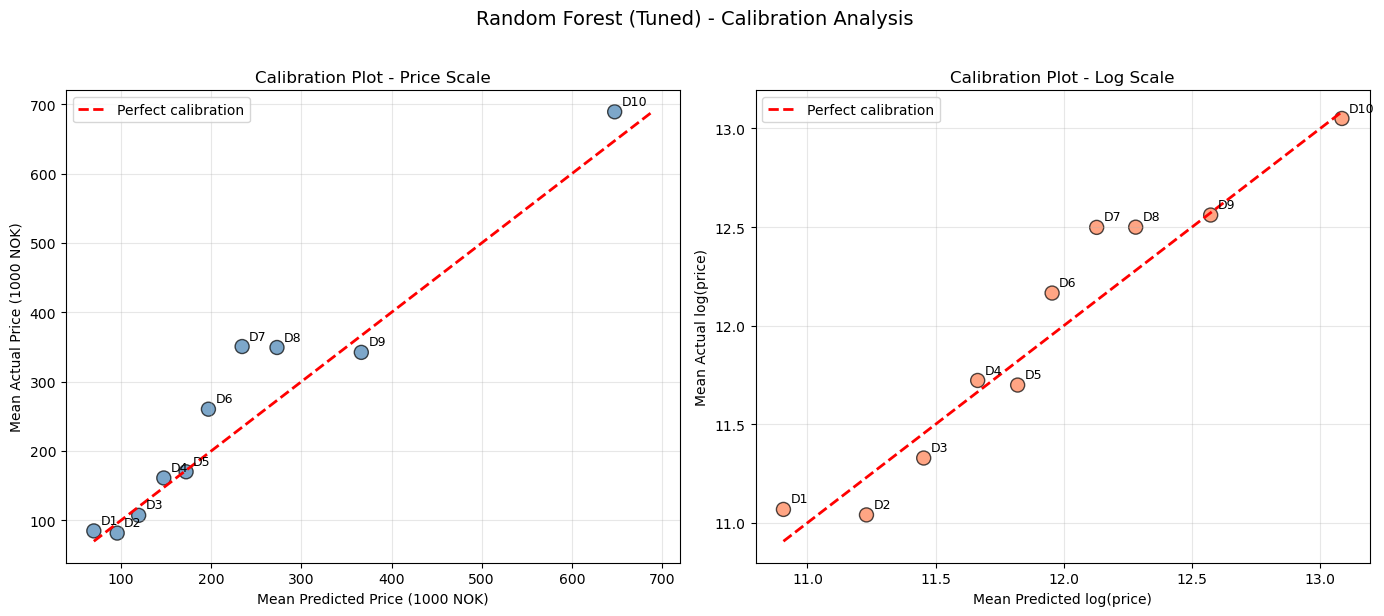


✓ Saved: rf_tuned_calibration_plot.png

[CALIBRATION ERROR METRICS]
  Expected Calibration Error (ECE): 37,937 NOK
  Maximum Calibration Error (MCE):  116,397 NOK (Decile 7)
  RMS Calibration Error (RMSCE):    51,470 NOK


In [97]:
# =========================================================
# CALIBRATION PLOT (TUNED MODEL)
# =========================================================

print("="*70)
print("CALIBRATION ANALYSIS (TUNED MODEL)")
print("="*70)

# Number of bins (deciles)
n_bins = 10

# Create bins based on predicted prices
pred_quantiles = pd.qcut(pred_test_price_tuned, q=n_bins, labels=False, duplicates='drop')

# Calculate mean predicted and actual for each bin
calibration_df = pd.DataFrame({
    'predicted': pred_test_price_tuned,
    'actual': y_test_price,
    'predicted_log': pred_test_tuned,
    'actual_log': y_test.values,
    'bin': pred_quantiles
})

calibration_summary = calibration_df.groupby('bin').agg(
    mean_predicted=('predicted', 'mean'),
    mean_actual=('actual', 'mean'),
    mean_predicted_log=('predicted_log', 'mean'),
    mean_actual_log=('actual_log', 'mean'),
    count=('actual', 'count')
).reset_index()

# Calculate differences
calibration_summary['diff_price'] = calibration_summary['mean_actual'] - calibration_summary['mean_predicted']
calibration_summary['diff_pct'] = (calibration_summary['diff_price'] / calibration_summary['mean_predicted']) * 100
calibration_summary['diff_log'] = calibration_summary['mean_actual_log'] - calibration_summary['mean_predicted_log']

print(f"\n[CALIBRATION BY PREDICTION DECILE]")
print(f"{'Decile':<8} {'Pred':>12} {'Actual':>12} {'Diff':>10} {'Diff %':>8} {'Pred Log':>10} {'Act Log':>10} {'Diff Log':>10} {'N':>5}")
print("-" * 95)

for _, row in calibration_summary.iterrows():
    print(f"D{int(row['bin'])+1:<7} {row['mean_predicted']:>12,.0f} {row['mean_actual']:>12,.0f} "
          f"{row['diff_price']:>+10,.0f} {row['diff_pct']:>+7.1f}% "
          f"{row['mean_predicted_log']:>10.3f} {row['mean_actual_log']:>10.3f} {row['diff_log']:>+10.3f} "
          f"{int(row['count']):>5}")

# Overall calibration metrics
mean_diff = (calibration_summary['mean_actual'] - calibration_summary['mean_predicted']).mean()
print(f"\n[CALIBRATION SUMMARY]")
print(f"  Mean difference across deciles: {mean_diff:+,.0f} NOK")

# Check for systematic bias
low_deciles = calibration_summary[calibration_summary['bin'] < 3]
high_deciles = calibration_summary[calibration_summary['bin'] >= 7]

low_bias = (low_deciles['mean_actual'] - low_deciles['mean_predicted']).mean()
high_bias = (high_deciles['mean_actual'] - high_deciles['mean_predicted']).mean()

print(f"  Low deciles (D1-D3) avg bias:   {low_bias:+,.0f} NOK")
print(f"  High deciles (D8-D10) avg bias: {high_bias:+,.0f} NOK")

if high_bias > 50000:
    print(f"  ⚠ Model underpredicts expensive horses")
elif high_bias < -50000:
    print(f"  ⚠ Model overpredicts expensive horses")
else:
    print(f"  ✓ Reasonably calibrated for expensive horses")

# =========================================================
# CALIBRATION PLOT
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Calibration plot (price scale)
ax1 = axes[0]
ax1.scatter(calibration_summary['mean_predicted']/1000, 
            calibration_summary['mean_actual']/1000,
            s=calibration_summary['count']*2,  # Size by count
            alpha=0.7, c='steelblue', edgecolor='black', linewidth=1)

# 45-degree reference line
max_val = max(calibration_summary['mean_predicted'].max(), 
              calibration_summary['mean_actual'].max()) / 1000
min_val = min(calibration_summary['mean_predicted'].min(), 
              calibration_summary['mean_actual'].min()) / 1000
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect calibration')

# Add decile labels
for _, row in calibration_summary.iterrows():
    ax1.annotate(f"D{int(row['bin'])+1}", 
                 (row['mean_predicted']/1000, row['mean_actual']/1000),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

ax1.set_xlabel('Mean Predicted Price (1000 NOK)')
ax1.set_ylabel('Mean Actual Price (1000 NOK)')
ax1.set_title('Calibration Plot - Price Scale')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Calibration plot (log scale)
#calibration_log = calibration_df.copy()
#calibration_log['predicted_log'] = np.log(calibration_log['predicted'])
#calibration_log['actual_log'] = np.log(calibration_log['actual'])

# Plot 2: Calibration plot (log scale) - use RAW log predictions
calibration_log_summary = calibration_df.groupby('bin').agg(
    mean_predicted_log=('predicted_log', 'mean'),  # Already has pred_test_tuned
    mean_actual_log=('actual_log', 'mean'),
    count=('actual', 'count')
).reset_index()

ax2 = axes[1]
ax2.scatter(calibration_log_summary['mean_predicted_log'], 
            calibration_log_summary['mean_actual_log'],
            s=calibration_log_summary['count']*2,
            alpha=0.7, c='coral', edgecolor='black', linewidth=1)



# 45-degree reference line
max_val_log = max(calibration_log_summary['mean_predicted_log'].max(), 
                  calibration_log_summary['mean_actual_log'].max())
min_val_log = min(calibration_log_summary['mean_predicted_log'].min(), 
                  calibration_log_summary['mean_actual_log'].min())
ax2.plot([min_val_log, max_val_log], [min_val_log, max_val_log], 'r--', lw=2, label='Perfect calibration')

# Add decile labels
for _, row in calibration_log_summary.iterrows():
    ax2.annotate(f"D{int(row['bin'])+1}", 
                 (row['mean_predicted_log'], row['mean_actual_log']),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

ax2.set_xlabel('Mean Predicted log(price)')
ax2.set_ylabel('Mean Actual log(price)')
ax2.set_title('Calibration Plot - Log Scale')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Random Forest (Tuned) - Calibration Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('rf_tuned_calibration_plot.svg', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: rf_tuned_calibration_plot.png")

# =========================================================
# CALIBRATION ERROR METRICS
# =========================================================

print(f"\n[CALIBRATION ERROR METRICS]")

# Expected Calibration Error (ECE) - weighted by bin size
weights = calibration_summary['count'] / calibration_summary['count'].sum()
abs_diff = np.abs(calibration_summary['mean_actual'] - calibration_summary['mean_predicted'])
log_diff = calibration_summary['mean_actual_log'] - calibration_summary['mean_predicted_log']
ece = (weights * abs_diff).sum()

print(f"  Expected Calibration Error (ECE): {ece:,.0f} NOK")

# Maximum Calibration Error (MCE)
mce = abs_diff.max()
print(f"  Maximum Calibration Error (MCE):  {mce:,.0f} NOK (Decile {abs_diff.argmax()+1})")

# Root Mean Square Calibration Error
rmsce = np.sqrt((weights * (calibration_summary['mean_actual'] - calibration_summary['mean_predicted'])**2).sum())
print(f"  RMS Calibration Error (RMSCE):    {rmsce:,.0f} NOK")

In [98]:
# ---------------------------------------------------------
# VALIDATION: Check Test R² for top CV candidates
# ---------------------------------------------------------
print("\n[VALIDATION: Comparing CV R² vs Test R²]")
print(f"  {'Parameters':<40} {'CV R²':>10} {'Test R²':>10}")
print(f"  {'-'*40} {'-'*10} {'-'*10}")

# Test a few regularization levels
validation_configs = [
    {'min_samples_leaf': 1, 'min_samples_split': 2},   # Least regularized (best CV)
    {'min_samples_leaf': 5, 'min_samples_split': 5},   # Moderate
    {'min_samples_leaf': 10, 'min_samples_split': 10}, # More regularized
    {'min_samples_leaf': 15, 'min_samples_split': 15}, # Most regularized
]

for config in validation_configs:
    params = {
        'n_estimators': best_n_est,
        'max_depth': best_depth,
        'max_features': best_max_feat,
        'max_samples': best_max_samp,
        'bootstrap': True,
        'random_state': 42,
        'n_jobs': -1,
        **config
    }
    
    # CV R²
    model = RandomForestRegressor(**params)
    cv_scores = cross_val_score(model, X_train.values, y_train.values, 
                                 cv=cv, groups=groups, scoring='r2')
    cv_r2 = cv_scores.mean()
    
    # Test R²
    model.fit(X_train.values, y_train.values)
    test_r2 = r2_score(y_test, model.predict(X_test.values))
    
    config_str = f"leaf={config['min_samples_leaf']}, split={config['min_samples_split']}"
    print(f"  {config_str:<40} {cv_r2:>10.4f} {test_r2:>10.4f}")



[VALIDATION: Comparing CV R² vs Test R²]
  Parameters                                    CV R²    Test R²
  ---------------------------------------- ---------- ----------
  leaf=1, split=2                              0.5337     0.4116
  leaf=5, split=5                              0.5355     0.4115
  leaf=10, split=10                            0.5168     0.4085
  leaf=15, split=15                            0.5009     0.3954
